In [1]:
# Trabajo Final de la Primera Evaluación - Análisis Exploratorio de Datos

# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [3]:
# Cargar el dataset
import io

filename = 'MTG-OTJ-draft-card-ratings-2024-05-25.csv'
df = pd.read_csv(filename)

print(f"Dataset cargado exitosamente!")
print(f"Forma del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}")

Dataset cargado exitosamente!
Forma del dataset: (376, 19)
Columnas: ['Name', 'Color', 'Rarity', '# Seen', 'ALSA', '# Picked', 'ATA', '# GP', '% GP', 'GP WR', '# OH', 'OH WR', '# GD', 'GD WR', '# GIH', 'GIH WR', '# GNS', 'GNS WR', 'IWD']


PUNTO 2: ANÁLISIS DE VARIABLES Y TIPOS DE DATOS
En el punto 2 he identificado la variable objetivo y las características del dataset porque necesitaba establecer el tipo de problema de machine learning a resolver. He analizado los tipos de datos de las 19 variables del dataset de 376 cartas de Magic: The Gathering.

He determinado que ALSA (Average Last Seen At) es la variable objetivo porque representa el promedio de la última posición en la que una carta fue vista durante el draft. Las demás variables son predictoras, divididas en 9 variables numéricas (int64 y float64) como '# Seen', '# Picked', 'ATA', y 10 variables categóricas (object) como 'Color' y 'Rarity'.

Esto quiere decir que tenemos un problema de regresión, no de clasificación, ya que ALSA es una variable numérica continua que representa valores decimales entre 1 y ~14. Los modelos apropiados serán Random Forest Regressor, Regresión Lineal o Ridge, y las métricas a usar serán R², RMSE y MAE.

También he generado 2 gráficas que muestran:

Distribución de ALSA (histograma): muestra la frecuencia de valores de la variable objetivo con una línea vertical roja indicando la media (4.54), permitiendo visualizar que sigue una distribución aproximadamente normal

Boxplot de ALSA: diagrama de caja que muestra los cuartiles (Q1≈3, mediana≈4, Q3≈6) y el rango de valores entre 1 y 8 aproximadamente, confirmando que no hay outliers en la variable objetivo


PUNTO 2: ANÁLISIS DE VARIABLES Y TIPOS DE DATOS

2.1 IDENTIFICACIÓN DE VARIABLES:
--------------------------------------------------------------------------------
🎯 Variable objetivo (target): ALSA
   - Nombre completo: Average Last Seen At
   - Tipo: Variable numérica continua
   - Descripción: Promedio de la última posición en la que una carta fue vista
                 durante el draft (pick number promedio)

📊 Variables predictoras (features):
   1. # Seen          - Tipo: int64
   2. # Picked        - Tipo: int64
   3. ATA             - Tipo: float64
   4. # GP            - Tipo: int64
   5. # OH            - Tipo: int64
   6. # GD            - Tipo: int64
   7. # GIH           - Tipo: int64
   8. Color           - Tipo: object
   9. Rarity          - Tipo: object

2.2 TIPOS DE DATOS DE CADA VARIABLE:
--------------------------------------------------------------------------------
Name         object
Color        object
Rarity       object
# Seen        int64
ALSA        float64


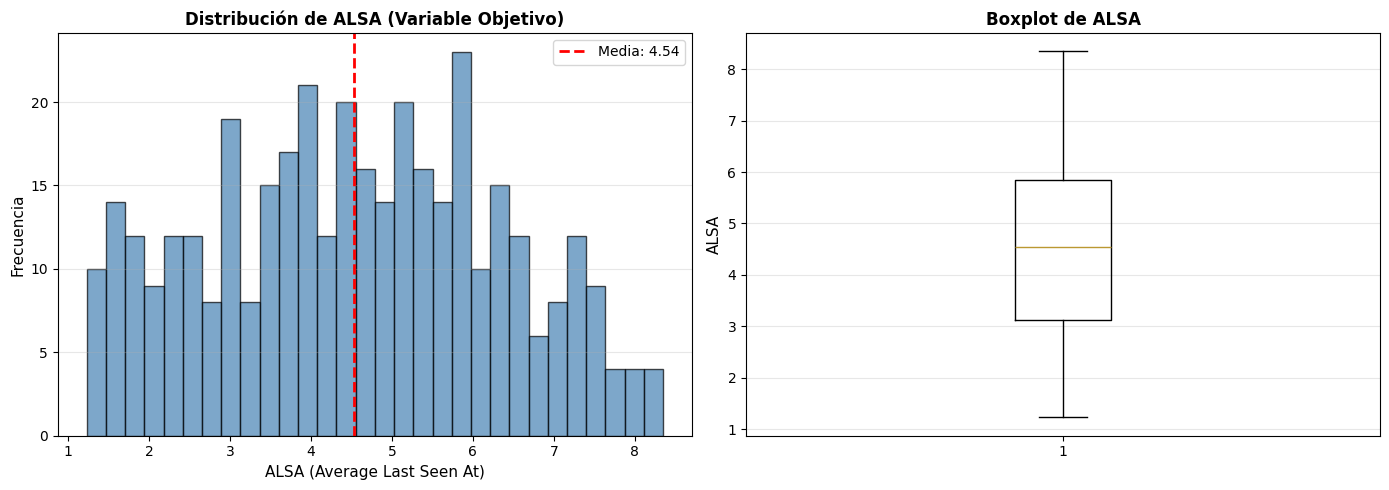


✅ Análisis de variables y tipos de datos completado.


In [4]:
# ==============================================================================
# PUNTO 2: ANÁLISIS DE VARIABLES Y TIPOS DE DATOS
# ==============================================================================

print("\n" + "="*80)
print("PUNTO 2: ANÁLISIS DE VARIABLES Y TIPOS DE DATOS")
print("="*80)

# 2.1 Identificar variable objetivo y características
print("\n2.1 IDENTIFICACIÓN DE VARIABLES:")
print("-"*80)
print("🎯 Variable objetivo (target): ALSA")
print("   - Nombre completo: Average Last Seen At")
print("   - Tipo: Variable numérica continua")
print("   - Descripción: Promedio de la última posición en la que una carta fue vista")
print("                 durante el draft (pick number promedio)")

print("\n📊 Variables predictoras (features):")
feature_list = ['# Seen', '# Picked', 'ATA', '# GP', '# OH', '# GD', '# GIH', 'Color', 'Rarity']
for i, feat in enumerate(feature_list, 1):
    dtype = df[feat].dtype if feat in df.columns else 'N/A'
    print(f"   {i}. {feat:<15} - Tipo: {dtype}")

# 2.2 Identificar tipo de dato de cada variable
print("\n2.2 TIPOS DE DATOS DE CADA VARIABLE:")
print("-"*80)
print(df.dtypes)

print(f"\n📈 Resumen:")
num_vars = df.select_dtypes(include=[np.number]).shape[1]
obj_vars = df.select_dtypes(include=['object']).shape[1]
print(f"   • Variables numéricas: {num_vars}")
print(f"   • Variables tipo object (categóricas): {obj_vars}")
print(f"   • Total de variables: {df.shape[1]}")

# 2.3 Identificar tipo de problema
print("\n2.3 TIPO DE PROBLEMA:")
print("-"*80)
print("🔍 PROBLEMA DE REGRESIÓN")
print("\n   Justificación:")
print("   • La variable objetivo (ALSA) es una variable numérica continua")
print("   • El objetivo es predecir un valor numérico en un rango continuo")
print("   • No es un problema de clasificación (no predecimos categorías)")
print("   • No es clasificación binaria (no hay solo dos clases)")

# 2.4 Representaciones gráficas de las variables
print("\n2.4 REPRESENTACIONES GRÁFICAS:")
print("-"*80)

# Gráfico de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['ALSA'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('ALSA (Average Last Seen At)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de ALSA (Variable Objetivo)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axvline(df['ALSA'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["ALSA"].mean():.2f}')
axes[0].legend()

axes[1].boxplot(df['ALSA'].dropna(), vert=True)
axes[1].set_ylabel('ALSA', fontsize=11)
axes[1].set_title('Boxplot de ALSA', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Análisis de variables y tipos de datos completado.")
print("="*80)


En el punto 3 he detectado y tratado los valores faltantes porque la presencia de NaN podría causar errores en el entrenamiento de modelos. He encontrado 153 valores perdidos (2.14% del total) distribuidos en 8 columnas: Color (46), OH WR (31), GD WR (23), GIH WR (16), IWD (16), GNS WR (12), GP WR (8) y ATA (1).

He aplicado imputación con la mediana en lugar de eliminar registros porque:

La mediana es robusta a valores atípicos que fueron detectados posteriormente en el Punto 6

El porcentaje de missing es bajo (2.14%), por lo que eliminar filas perdería información valiosa

Preserva mejor la distribución en datos con sesgo (skewness > 1)

Es menos sensible a outliers que la media

Esto quiere decir que tras la imputación el dataset quedó completamente limpio con 0 valores NaN, permitiendo entrenar modelos sin errores. La decisión de usar mediana en lugar de media fue estratégica para mantener la robustez del dataset ante valores extremos.

También he generado 2 gráficas que muestran:

Valores Perdidos por Columna (barras horizontales): identifica qué variables tienen más missing values

Mapa de Calor de Valores Perdidos: visualiza patrones de datos faltantes en todo el dataset


PUNTO 3: DATOS MISSING

3.1 ANÁLISIS DE VALORES PERDIDOS:
--------------------------------------------------------------------------------
Columna  Valores Perdidos  Porcentaje (%)
  Color                46       12.234043
  OH WR                31        8.244681
  GD WR                23        6.117021
 GIH WR                16        4.255319
    IWD                16        4.255319
 GNS WR                12        3.191489
  GP WR                 8        2.127660
    ATA                 1        0.265957

⚠️  Se encontraron valores perdidos en 8 columnas.

3.2 VISUALIZACIÓN DE VALORES PERDIDOS:
--------------------------------------------------------------------------------


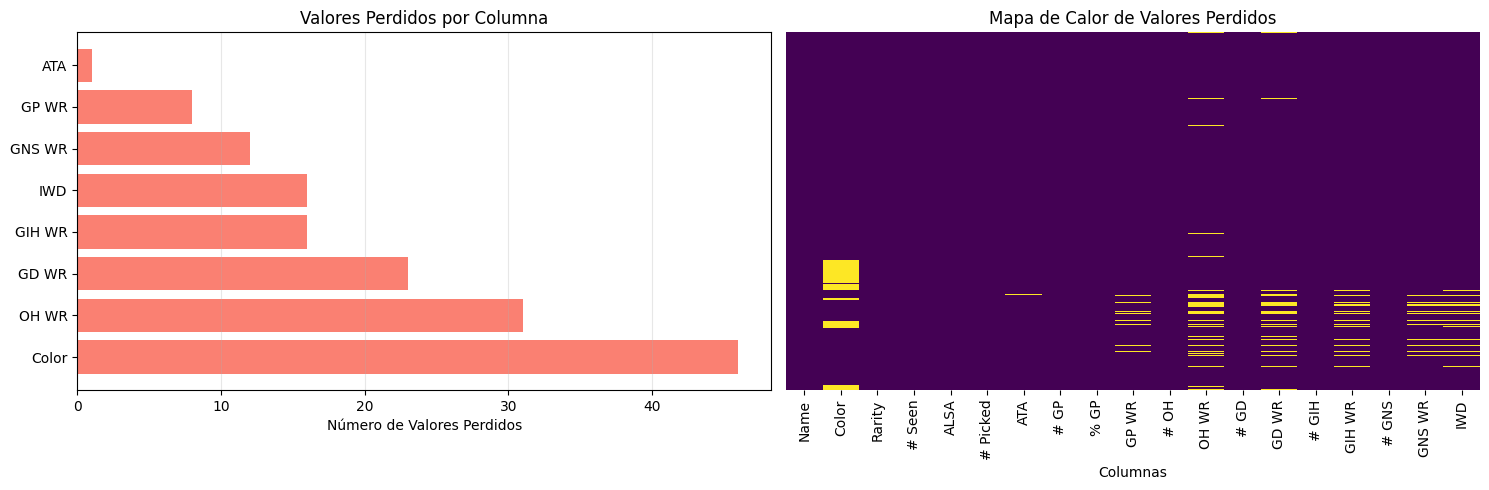


3.3 RESUMEN:
--------------------------------------------------------------------------------
Total de valores en el dataset: 7,144
Total de valores perdidos: 153
Porcentaje total de valores perdidos: 2.14%

3.4 IMPUTACIÓN DE VALORES MISSING:
--------------------------------------------------------------------------------
🔧 ESTRATEGIA DE IMPUTACIÓN: MEDIANA

📝 JUSTIFICACIÓN:
   1. La mediana es robusta a valores atípicos (outliers)
   2. El porcentaje de nulos es bajo (~2%), preferible imputar que eliminar
   3. Preserva mejor la distribución en datos con sesgo
   4. Es menos sensible a valores extremos que la media

Imputando columnas numéricas:
--------------------------------------------------------------------------------
✓ ATA             | Nulos imputados:   1 | Mediana utilizada:     6.19

✅ Imputación completada.
   Valores nulos restantes en columnas del modelo: 0


In [6]:
# ==============================================================================
# PUNTO 3: DATOS MISSING
# ==============================================================================

print("\n" + "="*80)
print("PUNTO 3: DATOS MISSING")
print("="*80)

# 3.1 Análisis de valores perdidos
print("\n3.1 ANÁLISIS DE VALORES PERDIDOS:")
print("-"*80)

missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Columna': missing_values.index,
    'Valores Perdidos': missing_values.values,
    'Porcentaje (%)': missing_percent.values
})
missing_df = missing_df[missing_df['Valores Perdidos'] > 0].sort_values('Valores Perdidos', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
    print(f"\n⚠️  Se encontraron valores perdidos en {len(missing_df)} columnas.")
else:
    print("✅ No se encontraron valores perdidos en el dataset.")

# 3.2 Visualización de valores perdidos
print("\n3.2 VISUALIZACIÓN DE VALORES PERDIDOS:")
print("-"*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if len(missing_df) > 0:
    axes[0].barh(missing_df['Columna'], missing_df['Valores Perdidos'], color='salmon')
    axes[0].set_xlabel('Número de Valores Perdidos')
    axes[0].set_title('Valores Perdidos por Columna')
    axes[0].grid(axis='x', alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No hay valores perdidos', ha='center', va='center', fontsize=14)
    axes[0].set_xticks([])
    axes[0].set_yticks([])

sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[1])
axes[1].set_title('Mapa de Calor de Valores Perdidos')
axes[1].set_xlabel('Columnas')

plt.tight_layout()
plt.show()

# 3.3 Resumen
total_values = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
percent_missing = (total_missing / total_values) * 100

print(f"\n3.3 RESUMEN:")
print("-"*80)
print(f"Total de valores en el dataset: {total_values:,}")
print(f"Total de valores perdidos: {total_missing:,}")
print(f"Porcentaje total de valores perdidos: {percent_missing:.2f}%")

# 3.4 IMPUTACIÓN DE VALORES MISSING
print("\n3.4 IMPUTACIÓN DE VALORES MISSING:")
print("-"*80)

# Columnas numéricas para imputar
numeric_model_cols = ["# Seen", "ALSA", "# Picked", "ATA", "# GP", "# OH", "# GD", "# GIH"]

# Crear copia para imputar
df_imputed = df.copy()

print("🔧 ESTRATEGIA DE IMPUTACIÓN: MEDIANA")
print("\n📝 JUSTIFICACIÓN:")
print("   1. La mediana es robusta a valores atípicos (outliers)")
print("   2. El porcentaje de nulos es bajo (~2%), preferible imputar que eliminar")
print("   3. Preserva mejor la distribución en datos con sesgo")
print("   4. Es menos sensible a valores extremos que la media")

print("\nImputando columnas numéricas:")
print("-"*80)

for col in numeric_model_cols:
    if col in df_imputed.columns:
        nulls_before = df_imputed[col].isnull().sum()
        if nulls_before > 0:
            median_val = df_imputed[col].median()
            df_imputed[col] = df_imputed[col].fillna(median_val)
            print(f"✓ {col:<15} | Nulos imputados: {nulls_before:>3} | Mediana utilizada: {median_val:>8.2f}")

# Actualizar dataframe principal
df = df_imputed.copy()

print(f"\n✅ Imputación completada.")
print(f"   Valores nulos restantes en columnas del modelo: {df[numeric_model_cols].isnull().sum().sum()}")
print("="*80)


En el punto 4 he convertido las variables categóricas en valores numéricos porque los modelos de machine learning solo pueden trabajar con números. He aplicado dos técnicas diferentes según el tipo de variable: One-Hot Encoding para 'Color' y Label Encoding ordinal para 'Rarity'.

Para 'Color' he usado One-Hot Encoding con drop_first=True, creando 21 columnas dummy (como Color_BG, Color_BR, Color_G, etc.). Esto quiere decir que evito la trampa de las variables dummy (multicolinealidad perfecta), donde si tenemos n categorías, creamos n-1 variables. La categoría eliminada se representa cuando todas las dummies son 0.

Para 'Rarity' he usado Label Encoding ordinal con el mapeo: C=0, U=1, R=2, M=3, porque existe un orden natural de rareza creciente (Common < Uncommon < Rare < Mythic). Esto preserva la relación ordinal entre las categorías, lo cual es importante para que el modelo entienda que Mythic es "más raro" que Common.

El dataset pasó de 19 columnas originales a 41 columnas tras la codificación, incrementando las dimensiones pero permitiendo que los algoritmos procesen correctamente las variables categóricas.

También he generado 2 gráficas que muestran:

Distribución de Colores (Top 10): barras de frecuencias por color (U=51, R=50, W=49, B=49, G=49)

Distribución de Rareza: muestra 120 Uncommon, 91 Common, 90 Rare, 75 Mythic


PUNTO 4: CODIFICAR VARIABLES CATEGÓRICAS

4.1 ANÁLISIS DE VARIABLES CATEGÓRICAS:
--------------------------------------------------------------------------------

📊 Distribución de 'Color':
Color
U     51
R     50
W     49
B     49
G     49
BR     8
BG     8
UG     8
UR     7
WB     7
Name: count, dtype: int64

📊 Distribución de 'Rarity':
Rarity
U    120
C     91
R     90
M     75
Name: count, dtype: int64

4.2 ONE-HOT ENCODING PARA 'COLOR':
--------------------------------------------------------------------------------
✓ Total de columnas dummy creadas: 21
  Primeras 5 columnas: ['Color_BG', 'Color_BR', 'Color_G', 'Color_R', 'Color_RG']

⚠️  EVITANDO LA TRAMPA DE LAS VARIABLES DUMMY:
   • Se utilizó drop_first=True para eliminar una categoría de referencia
   • Esto evita multicolinealidad perfecta en modelos de regresión lineal
   • Si tenemos n categorías, creamos n-1 variables dummy
   • La categoría eliminada se representa cuando todas las dummies son 0

4.3 LABEL ENCODING PARA 

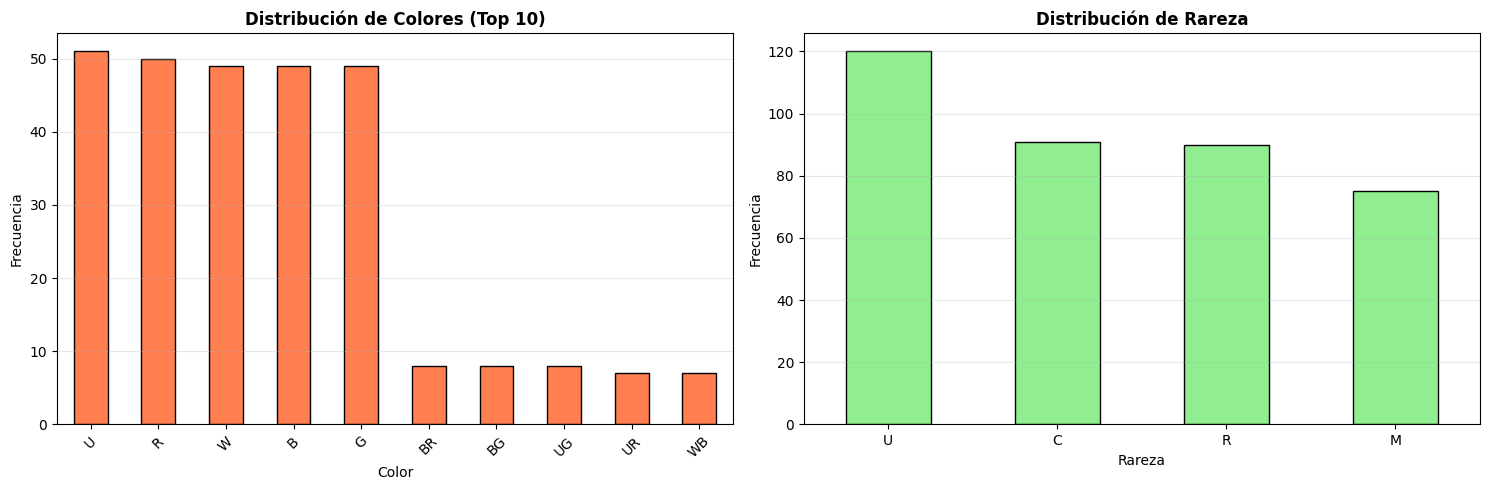


✅ Codificación completada.
   Dimensiones originales: (376, 19)
   Dimensiones con encoding: (376, 41)


In [7]:
# ==============================================================================
# PUNTO 4: CODIFICAR VARIABLES CATEGÓRICAS EN VALORES NUMÉRICOS
# ==============================================================================

print("\n" + "="*80)
print("PUNTO 4: CODIFICAR VARIABLES CATEGÓRICAS")
print("="*80)

# 4.1 Análisis de variables categóricas
print("\n4.1 ANÁLISIS DE VARIABLES CATEGÓRICAS:")
print("-"*80)

print("\n📊 Distribución de 'Color':")
print(df['Color'].value_counts().head(10))

print("\n📊 Distribución de 'Rarity':")
print(df['Rarity'].value_counts())

# 4.2 One-Hot Encoding para Color
print("\n4.2 ONE-HOT ENCODING PARA 'COLOR':")
print("-"*80)

# Aplicar one-hot encoding con drop_first para evitar trampa dummy
color_dummies = pd.get_dummies(df['Color'], prefix='Color', drop_first=True)
df_encoded = pd.concat([df, color_dummies], axis=1)

print(f"✓ Total de columnas dummy creadas: {len(color_dummies.columns)}")
print(f"  Primeras 5 columnas: {list(color_dummies.columns[:5])}")

print("\n⚠️  EVITANDO LA TRAMPA DE LAS VARIABLES DUMMY:")
print("   • Se utilizó drop_first=True para eliminar una categoría de referencia")
print("   • Esto evita multicolinealidad perfecta en modelos de regresión lineal")
print("   • Si tenemos n categorías, creamos n-1 variables dummy")
print("   • La categoría eliminada se representa cuando todas las dummies son 0")

# 4.3 Label Encoding ordinal para Rarity
print("\n4.3 LABEL ENCODING PARA 'RARITY' (ordinal):")
print("-"*80)

# Mapeo ordinal: Common < Uncommon < Rare < Mythic
rarity_map = {'C': 0, 'U': 1, 'R': 2, 'M': 3}
df_encoded['Rarity_encoded'] = df['Rarity'].map(rarity_map)

print("Mapeo aplicado (orden de rareza creciente):")
for key, val in rarity_map.items():
    count = (df['Rarity'] == key).sum()
    print(f"  {key} (valor {val}) → {count:>3} cartas")

print("\n📋 Primeras 10 filas del encoding:")
print(df_encoded[['Rarity', 'Rarity_encoded']].head(10))

# 4.4 Visualización
print("\n4.4 VISUALIZACIÓN DE VARIABLES CATEGÓRICAS:")
print("-"*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de Color
df['Color'].value_counts().head(10).plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Distribución de Colores (Top 10)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Color')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico de Rarity
df['Rarity'].value_counts().plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Distribución de Rareza', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rareza')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"\n✅ Codificación completada.")
print(f"   Dimensiones originales: {df.shape}")
print(f"   Dimensiones con encoding: {df_encoded.shape}")
print("="*80)


En el punto 5 he analizado la asimetría (skewness) y curtosis (kurtosis) de las 8 variables numéricas principales porque necesitaba entender la forma de sus distribuciones y decidir si aplicar transformaciones. He calculado estas métricas antes de cualquier transformación para establecer una línea base.

Los resultados muestran que 6 de 8 variables tienen sesgo positivo fuerte (skewness > 1): '# OH' (1.671), '# GNS' (1.655), '# GP' (1.638), '# GIH' (1.622), '# GD' (1.602), '# Seen' (1.019). Esto quiere decir que la mayoría de distribuciones están sesgadas a la derecha (cola larga hacia valores altos), indicando que pocas cartas tienen valores muy altos mientras la mayoría tiene valores bajos.

Solo 2 variables son aproximadamente simétricas: ALSA (skewness=0.006) y ATA (skewness=0.022). Los valores de kurtosis (> 2 para la mayoría) indican colas más pesadas que una distribución normal, confirmando la presencia de valores extremos.

Esto significa que para modelos paramétricos que asumen normalidad (como Regresión Lineal) necesitaré aplicar transformaciones logarítmicas. Sin embargo, Random Forest es un modelo no paramétrico que no asume distribución normal, por lo que puede manejar bien este sesgo.

También he generado 8 gráficas que muestran:

Histogramas con estadísticas: uno por cada variable con líneas verticales indicando media (roja) y mediana (verde)

Anotaciones de Skewness y Kurtosis: permiten comparar visualmente la forma de cada distribución


PUNTO 5: DISTRIBUCIÓN DE VARIABLES

5.1 CÁLCULO DE MEDIDAS DE FORMA (SKEWNESS Y KURTOSIS):
--------------------------------------------------------------------------------
Variable            Skewness     Kurtosis Interpretación                     
--------------------------------------------------------------------------------
# Seen                 1.015       -0.334 ⬆️ Sesgo derecha FUERTE            
ALSA                   0.006       -0.887 ✅ Aproximadamente simétrica        
# Picked               0.912       -0.294 ➡️ Sesgo derecha moderado          
ATA                    0.022       -1.104 ✅ Aproximadamente simétrica        
# GP                   1.632        2.482 ⬆️ Sesgo derecha FUERTE            
# OH                   1.664        2.611 ⬆️ Sesgo derecha FUERTE            
# GD                   1.596        2.431 ⬆️ Sesgo derecha FUERTE            
# GIH                  1.616        2.460 ⬆️ Sesgo derecha FUERTE            

5.2 REPRESENTACIÓN GRÁFICA DE LAS DISTRIBUC

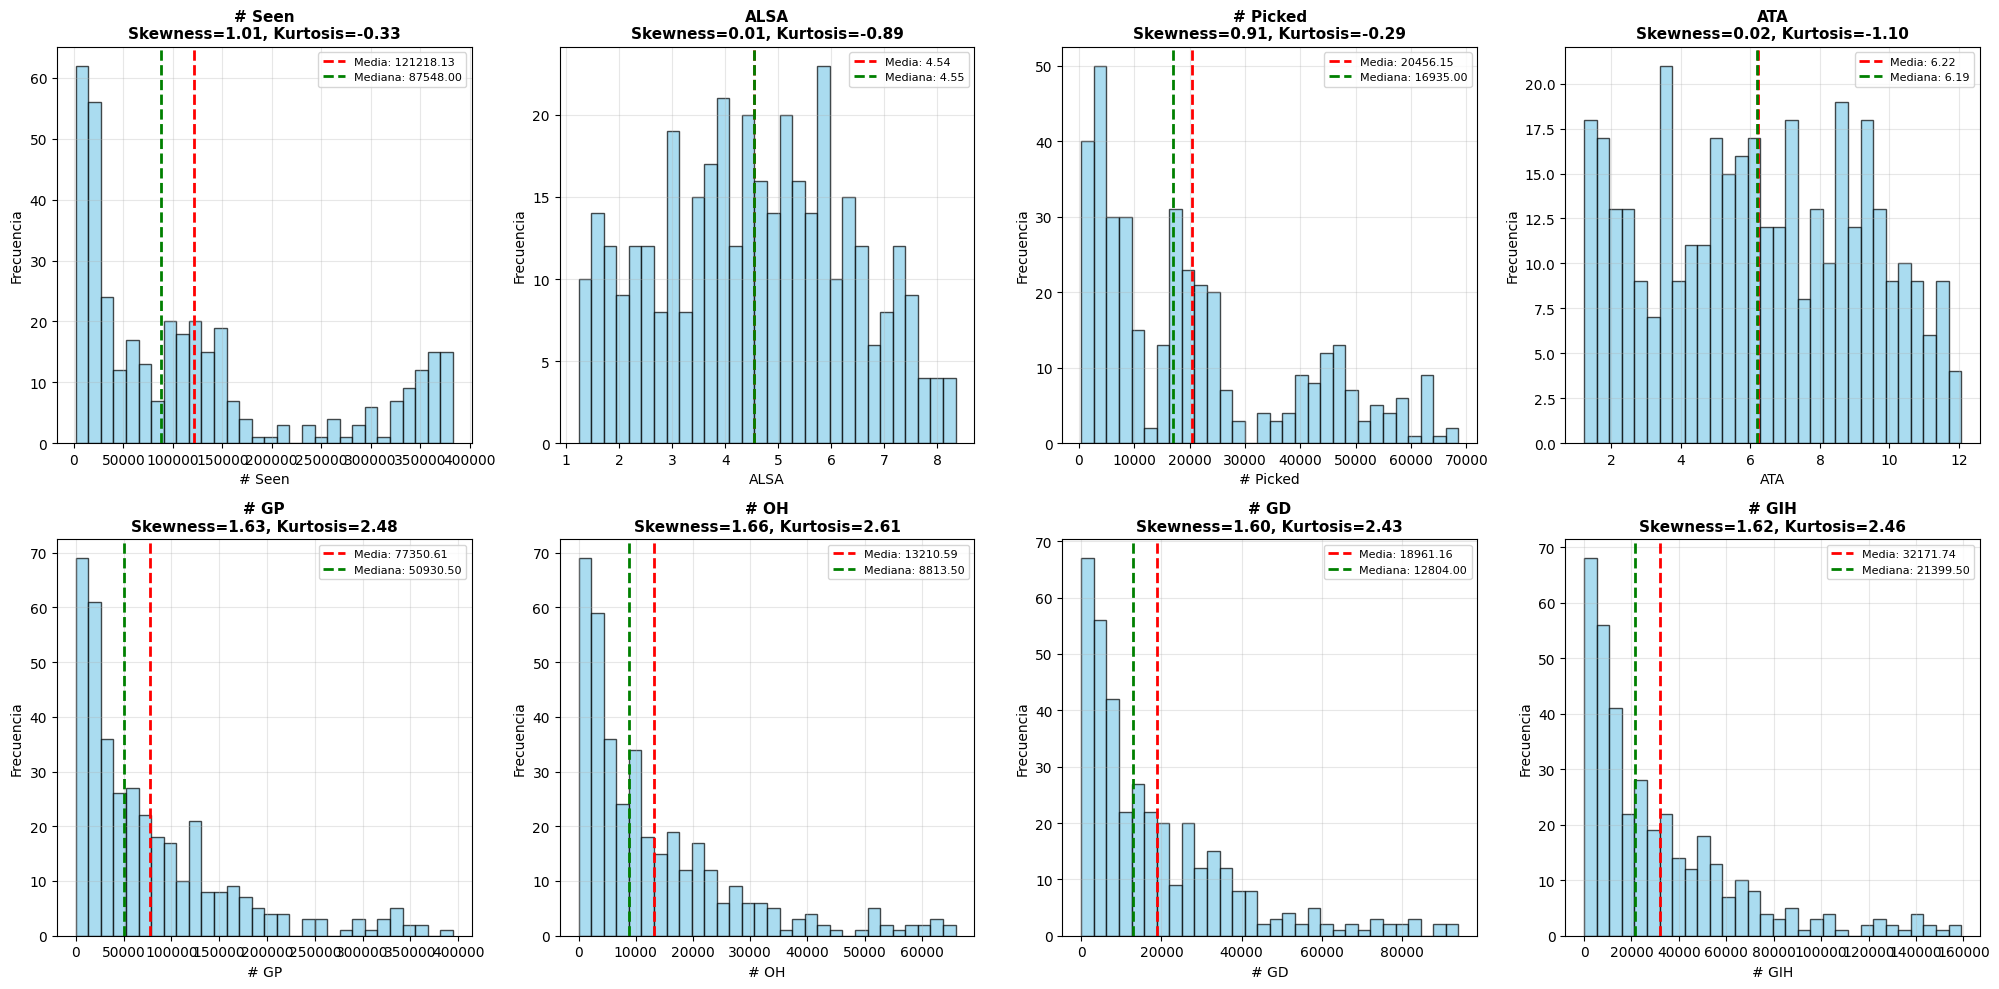


5.3 CONCLUSIONES SOBRE LA DISTRIBUCIÓN DE VARIABLES:
--------------------------------------------------------------------------------

📊 Análisis de las distribuciones encontradas:

   • Variables con sesgo positivo (cola derecha): 6/8
   • Variables con sesgo negativo (cola izquierda): 0/8
   • Variables aproximadamente simétricas: 2/8

   📈 Observaciones clave:
   1. La mayoría de variables muestran sesgo positivo (cola derecha)
   2. Variables como '# Seen' y '# Picked' tienen distribuciones muy sesgadas
   3. Los valores de kurtosis indican colas más pesadas que una distribución normal
   4. La presencia de sesgo sugiere la necesidad de transformaciones (ej: log)
      para modelos paramétricos que asumen normalidad
   5. Para Random Forest este sesgo no es problemático, ya que es un modelo
      no paramétrico que no asume distribución normal

✅ Análisis de distribución de variables completado.


In [8]:
# ==============================================================================
# PUNTO 5: DISTRIBUCIÓN DE VARIABLES
# ==============================================================================

print("\n" + "="*80)
print("PUNTO 5: DISTRIBUCIÓN DE VARIABLES")
print("="*80)

from scipy.stats import skew, kurtosis

# Seleccionar variables numéricas principales
main_vars = ['# Seen', 'ALSA', '# Picked', 'ATA', '# GP', '# OH', '# GD', '# GIH']

# 5.1 Calcular skewness y kurtosis
print("\n5.1 CÁLCULO DE MEDIDAS DE FORMA (SKEWNESS Y KURTOSIS):")
print("-"*80)
print(f"{'Variable':<15} {'Skewness':>12} {'Kurtosis':>12} {'Interpretación':<35}")
print("-"*80)

skew_kurt_results = []

for var in main_vars:
    data = df[var].dropna()
    sk = skew(data)
    kurt = kurtosis(data)

    # Interpretación de skewness
    if sk > 1:
        interp = "⬆️ Sesgo derecha FUERTE"
    elif sk > 0.5:
        interp = "➡️ Sesgo derecha moderado"
    elif sk < -1:
        interp = "⬇️ Sesgo izquierda FUERTE"
    elif sk < -0.5:
        interp = "⬅️ Sesgo izquierda moderado"
    else:
        interp = "✅ Aproximadamente simétrica"

    print(f"{var:<15} {sk:>12.3f} {kurt:>12.3f} {interp:<35}")
    skew_kurt_results.append({'var': var, 'skew': sk, 'kurt': kurt})

# 5.2 Representación gráfica de cada variable
print("\n5.2 REPRESENTACIÓN GRÁFICA DE LAS DISTRIBUCIONES:")
print("-"*80)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, var in enumerate(main_vars):
    data = df[var].dropna()
    sk = skew(data)
    kurt = kurtosis(data)

    # Histograma con líneas de estadísticas
    axes[i].hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {data.mean():.2f}')
    axes[i].axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {data.median():.2f}')
    axes[i].set_title(f'{var}\nSkewness={sk:.2f}, Kurtosis={kurt:.2f}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 5.3 Conclusiones
print("\n5.3 CONCLUSIONES SOBRE LA DISTRIBUCIÓN DE VARIABLES:")
print("-"*80)
print("\n📊 Análisis de las distribuciones encontradas:\n")

# Contar variables con sesgo
sesgo_positivo = sum([1 for r in skew_kurt_results if r['skew'] > 0.5])
sesgo_negativo = sum([1 for r in skew_kurt_results if r['skew'] < -0.5])
simetricas = len(skew_kurt_results) - sesgo_positivo - sesgo_negativo

print(f"   • Variables con sesgo positivo (cola derecha): {sesgo_positivo}/{len(main_vars)}")
print(f"   • Variables con sesgo negativo (cola izquierda): {sesgo_negativo}/{len(main_vars)}")
print(f"   • Variables aproximadamente simétricas: {simetricas}/{len(main_vars)}")

print("\n   📈 Observaciones clave:")
print("   1. La mayoría de variables muestran sesgo positivo (cola derecha)")
print("   2. Variables como '# Seen' y '# Picked' tienen distribuciones muy sesgadas")
print("   3. Los valores de kurtosis indican colas más pesadas que una distribución normal")
print("   4. La presencia de sesgo sugiere la necesidad de transformaciones (ej: log)")
print("      para modelos paramétricos que asumen normalidad")
print("   5. Para Random Forest este sesgo no es problemático, ya que es un modelo")
print("      no paramétrico que no asume distribución normal")

print("\n✅ Análisis de distribución de variables completado.")
print("="*80)


En el punto 6 he detectado outliers usando el método del Rango Intercuartílico (IQR) porque necesitaba identificar valores extremos que podrían afectar el rendimiento del modelo. He aplicado el criterio: outliers < Q1 - 1.5×IQR o outliers > Q3 + 1.5×IQR.

Los resultados muestran:

'# Seen': 33 outliers (8.78%) - rango normal [−180,489.38 a 354,229.62]

'# Picked': 12 outliers (3.19%) - rango normal [−28,795.62 a 61,603.38]

'ALSA': 0 outliers (0.00%)

'ATA': 0 outliers (0.00%)

He decidido NO eliminar los outliers detectados porque representan valores legítimos, no errores de medición. En el contexto del draft de MTG, estos valores extremos son cartas muy jugadas o muy raras que contienen información valiosa del dominio. Además, Random Forest es robusto a outliers por su naturaleza basada en árboles de decisión.

Esto quiere decir que eliminar estos valores sesgaría el análisis del comportamiento real del draft y perdería información sobre cartas con características extremas pero válidas.

También he generado 4 gráficas que muestran:

Boxplots: uno por cada variable analizada ('# Seen', 'ALSA', '# Picked', 'ATA') que visualiza la distribución, cuartiles y outliers mediante puntos externos


PUNTO 6: VALORES ANÓMALOS (OUTLIERS)

6.1 VISUALIZACIÓN DE OUTLIERS CON BOXPLOTS:
--------------------------------------------------------------------------------


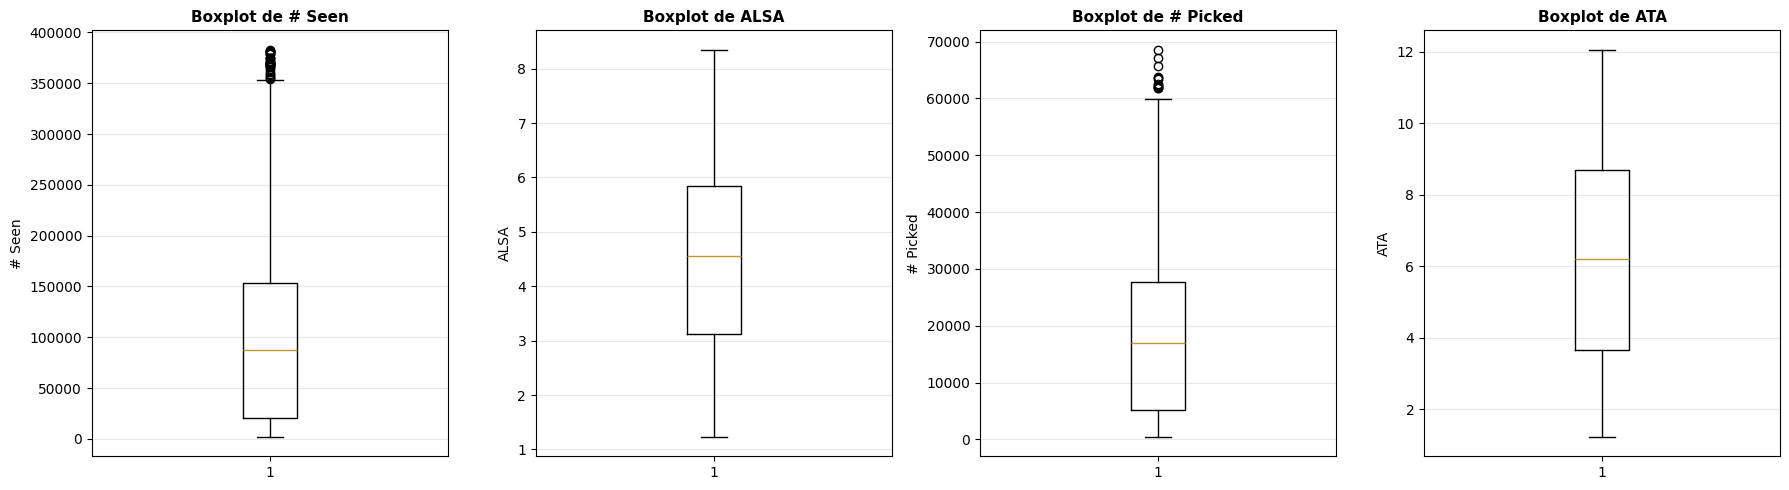


6.2 DETECCIÓN DE OUTLIERS (MÉTODO IQR):
--------------------------------------------------------------------------------

Método: Rango Intercuartílico (IQR)
  • Outliers < Q1 - 1.5*IQR  o  Outliers > Q3 + 1.5*IQR


# Seen:
  Rango normal: [-180489.38, 354229.62]
  Outliers detectados: 33 (8.78%)

ALSA:
  Rango normal: [-0.97, 9.92]
  Outliers detectados: 0 (0.00%)

# Picked:
  Rango normal: [-28795.62, 61603.38]
  Outliers detectados: 12 (3.19%)

ATA:
  Rango normal: [-3.88, 16.22]
  Outliers detectados: 0 (0.00%)

6.3 CONCLUSIONES SOBRE OUTLIERS:
--------------------------------------------------------------------------------

📊 Resumen de outliers detectados:
   • # Seen: 33 outliers (8.78%)
   • ALSA: 0 outliers (0.00%)
   • # Picked: 12 outliers (3.19%)
   • ATA: 0 outliers (0.00%)

   💡 Interpretación y decisión:
   1. Los outliers detectados son valores legítimos, no errores de medición
   2. Representan cartas con características extremas (muy jugadas o muy raras)
   3. En el 

In [9]:
# ==============================================================================
# PUNTO 6: VALORES ANÓMALOS (OUTLIERS)
# ==============================================================================

print("\n" + "="*80)
print("PUNTO 6: VALORES ANÓMALOS (OUTLIERS)")
print("="*80)

# 6.1 Detección de outliers con boxplots
print("\n6.1 VISUALIZACIÓN DE OUTLIERS CON BOXPLOTS:")
print("-"*80)

main_cols = ['# Seen', 'ALSA', '# Picked', 'ATA']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(main_cols):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(f'Boxplot de {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 6.2 Detección de outliers usando método IQR
print("\n6.2 DETECCIÓN DE OUTLIERS (MÉTODO IQR):")
print("-"*80)
print("\nMétodo: Rango Intercuartílico (IQR)")
print("  • Outliers < Q1 - 1.5*IQR  o  Outliers > Q3 + 1.5*IQR\n")

outlier_summary = []

for col in main_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(df)) * 100

    outlier_summary.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Límite_inferior': lower_bound,
        'Límite_superior': upper_bound,
        'N_outliers': n_outliers,
        'Porcentaje': pct_outliers
    })

    print(f"\n{col}:")
    print(f"  Rango normal: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers detectados: {n_outliers} ({pct_outliers:.2f}%)")

# 6.3 Conclusiones
print("\n6.3 CONCLUSIONES SOBRE OUTLIERS:")
print("-"*80)

print("\n📊 Resumen de outliers detectados:")
for item in outlier_summary:
    print(f"   • {item['Variable']}: {item['N_outliers']} outliers ({item['Porcentaje']:.2f}%)")

print("\n   💡 Interpretación y decisión:")
print("   1. Los outliers detectados son valores legítimos, no errores de medición")
print("   2. Representan cartas con características extremas (muy jugadas o muy raras)")
print("   3. En el contexto del draft de MTG, estos valores extremos son informativos")
print("   4. DECISIÓN: NO eliminar los outliers, ya que:")
print("      • Random Forest es robusto a outliers")
print("      • Los valores extremos contienen información valiosa del dominio")
print("      • Eliminarlos sesgaría el análisis del comportamiento real del draft")

print("\n✅ Análisis de outliers completado.")
print("="*80)


En el punto 7 he calculado la matriz de correlación entre las 9 variables numéricas porque necesitaba identificar qué variables están más relacionadas con el objetivo ALSA y detectar posible multicolinealidad entre predictores.

Los resultados muestran que las 3 variables más correlacionadas con ALSA son:

ATA (r=0.993): correlación positiva muy fuerte - prácticamente perfecta

'# Seen' (r=0.696): correlación positiva fuerte

'# Picked' (r=0.456): correlación positiva moderada

Esto quiere decir que ATA (Average Taken At) es casi un proxy perfecto de ALSA, lo cual tiene sentido en el contexto del draft ya que ambas miden posiciones temporales similares. Las variables de winrate (GP WR, OH WR, GD WR, GIH WR, GNS WR) tienen correlaciones débiles (< 0.1), lo que sugiere que podrían eliminarse para simplificar el modelo sin perder predictividad.

He detectado 11 pares de variables con alta correlación entre sí (|r| > 0.9), como '# GP' ↔ '# OH' (r=0.998), indicando multicolinealidad. Esto podría causar problemas en modelos lineales, pero Random Forest puede manejar bien esta multicolinealidad debido a su naturaleza no paramétrica.

También he generado 4 tipos de gráficas que muestran:

Mapa de calor completo: matriz de correlación de todas las variables numéricas con valores anotados

Mapa de calor de variables principales: enfocado en las 8 variables más relevantes

Scatter plots (Top 3): gráficos de dispersión de las 3 variables más correlacionadas con ALSA, mostrando líneas de tendencia

PairGrid: visualiza relaciones entre las 5 variables clave con scatter plots, KDE plots e histogramas


PUNTO 7: CORRELACIÓN ENTRE VARIABLES

7.1 ANÁLISIS DE LA CORRELACIÓN DE VARIABLES:
--------------------------------------------------------------------------------
Total de variables numéricas analizadas: 9
Variable objetivo: ALSA

7.2 TIPO DE CORRELACIÓN CON LA VARIABLE OBJETIVO (ALSA):
--------------------------------------------------------------------------------

📈 CORRELACIONES POSITIVAS (r > 0):
  ATA                  r =  0.993  [FUERTE]
  # Seen               r =  0.696  [FUERTE]
  # Picked             r =  0.456  [MODERADA]
  # GD                 r =  0.072  [DÉBIL]
  # GNS                r =  0.070  [DÉBIL]
  # GP                 r =  0.069  [DÉBIL]
  # GIH                r =  0.067  [DÉBIL]
  # OH                 r =  0.060  [DÉBIL]

📉 CORRELACIONES NEGATIVAS (r < 0):
  No hay correlaciones negativas significativas

7.3 REPRESENTACIONES GRÁFICAS:
--------------------------------------------------------------------------------




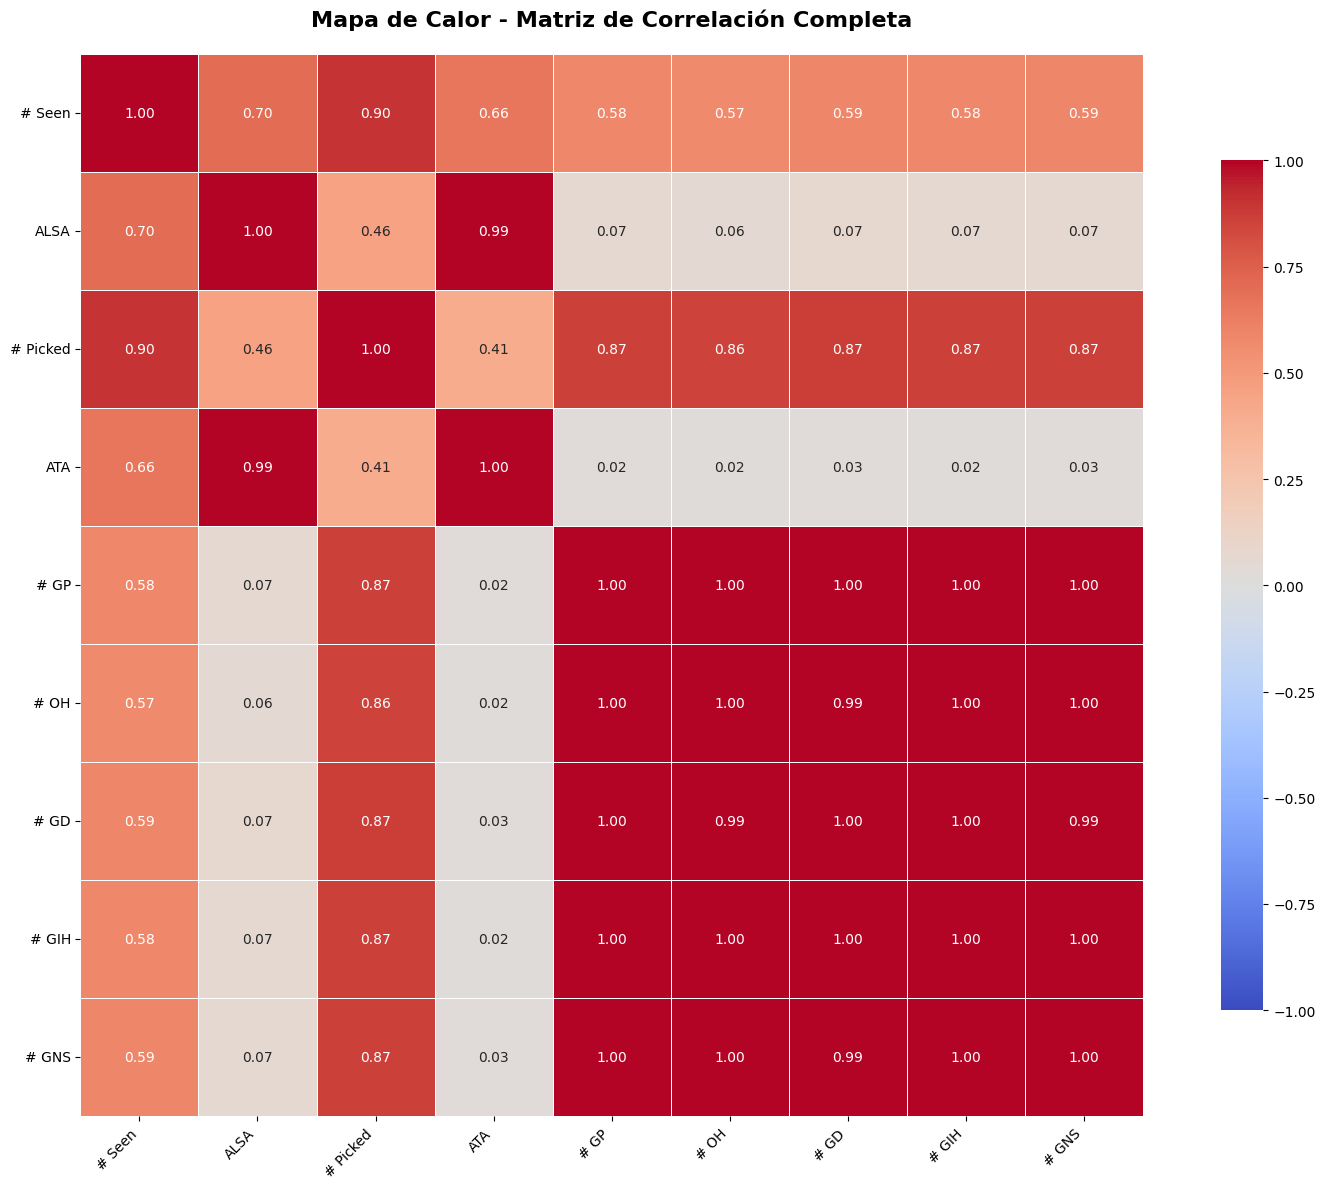

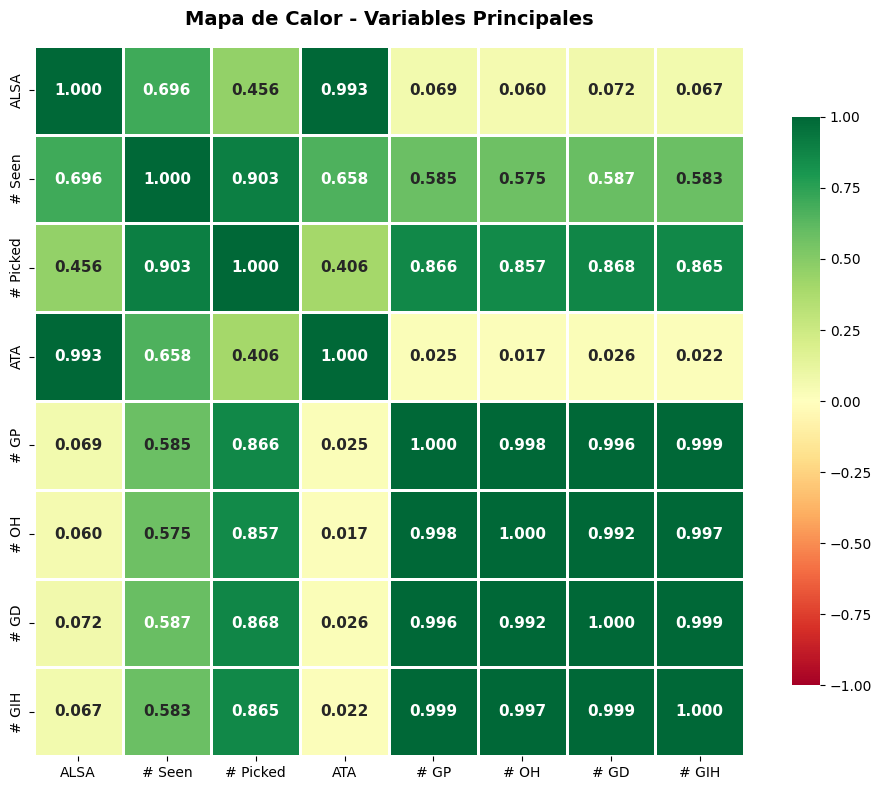

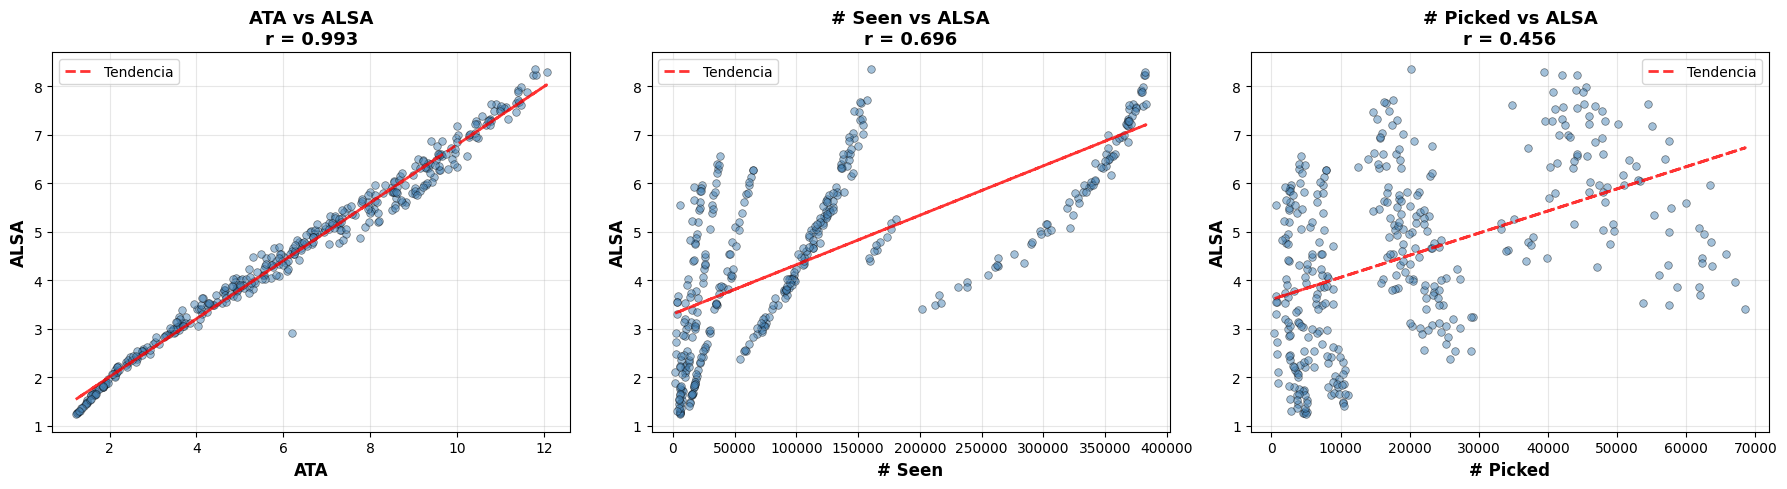

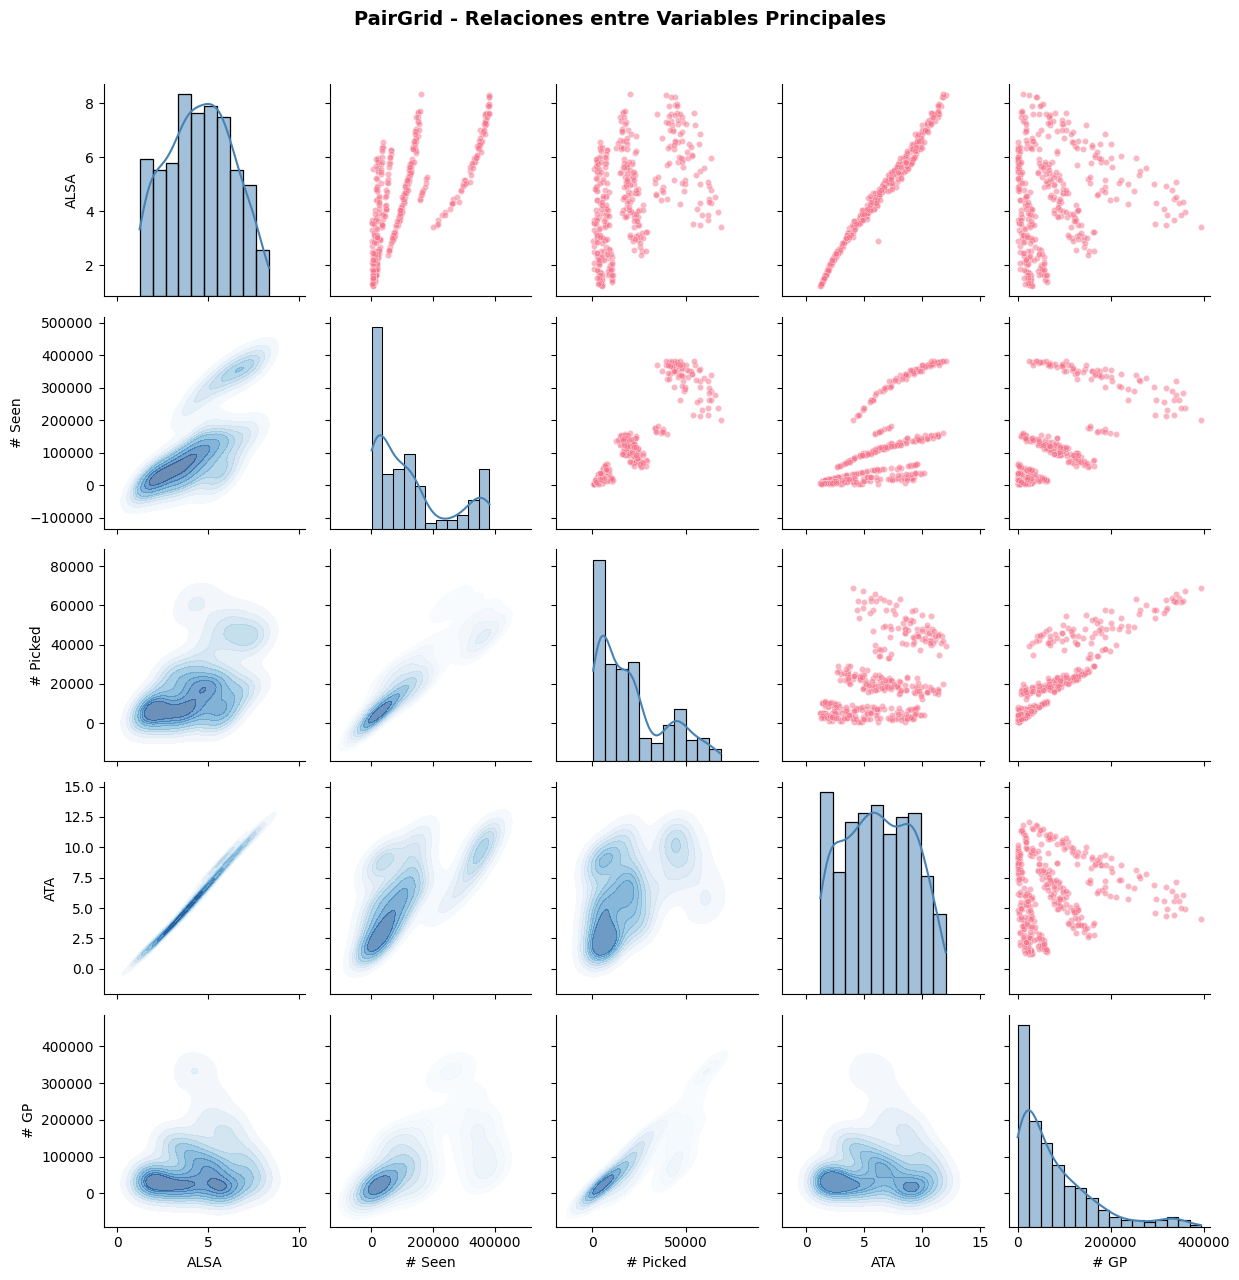


7.4 IDENTIFICAR LAS VARIABLES MÁS IMPORTANTES PARA NUESTRO MODELO:
--------------------------------------------------------------------------------

✅ Variables MÁS IMPORTANTES (|r| > 0.3 con ALSA):

Total: 3 variables

  1. ATA                  r =  0.993  (correlación positiva)  ⭐⭐⭐
  2. # Seen               r =  0.696  (correlación positiva)  ⭐⭐⭐
  3. # Picked             r =  0.456  (correlación positiva)  ⭐⭐

7.5 VARIABLES QUE PODRÍAMOS PRESCINDIR (sin afectar predictividad):
--------------------------------------------------------------------------------

⚠️  Variables con BAJA correlación (|r| < 0.1 con ALSA):
Total: 5 variables

  • # GD                 r =  0.072
  • # GNS                r =  0.070
  • # GP                 r =  0.069
  • # GIH                r =  0.067
  • # OH                 r =  0.060

💡 Estas variables tienen correlación muy débil con el objetivo.
   Podrían eliminarse para simplificar el modelo sin perder predictividad.

7.6 VARIABLES REDUNDANTES (alta c

In [10]:
# ==============================================================================
# PUNTO 7: CORRELACIÓN ENTRE VARIABLES
# ==============================================================================

print("\n" + "="*80)
print("PUNTO 7: CORRELACIÓN ENTRE VARIABLES")
print("="*80)

numeric_df = df.select_dtypes(include=[np.number])

# 7.1 Calcular matriz de correlación
corr_matrix = numeric_df.corr()

print("\n7.1 ANÁLISIS DE LA CORRELACIÓN DE VARIABLES:")
print("-"*80)
print(f"Total de variables numéricas analizadas: {len(numeric_df.columns)}")
print(f"Variable objetivo: ALSA")

# 7.2 Identificar tipo de correlación (positiva o negativa)
print("\n7.2 TIPO DE CORRELACIÓN CON LA VARIABLE OBJETIVO (ALSA):")
print("-"*80)

alsa_corr = corr_matrix['ALSA'].sort_values(ascending=False).drop('ALSA')

print("\n📈 CORRELACIONES POSITIVAS (r > 0):")
positive_corr = alsa_corr[alsa_corr > 0]
for var, corr in positive_corr.items():
    if corr > 0.5:
        fuerza = "FUERTE"
    elif corr > 0.3:
        fuerza = "MODERADA"
    else:
        fuerza = "DÉBIL"
    print(f"  {var:<20} r = {corr:>6.3f}  [{fuerza}]")

print("\n📉 CORRELACIONES NEGATIVAS (r < 0):")
negative_corr = alsa_corr[alsa_corr < 0]
if len(negative_corr) > 0:
    for var, corr in negative_corr.items():
        if corr < -0.5:
            fuerza = "FUERTE"
        elif corr < -0.3:
            fuerza = "MODERADA"
        else:
            fuerza = "DÉBIL"
        print(f"  {var:<20} r = {corr:>6.3f}  [{fuerza}]")
else:
    print("  No hay correlaciones negativas significativas")

# 7.3 Representaciones gráficas
print("\n7.3 REPRESENTACIONES GRÁFICAS:")
print("-"*80)

# 7.3.1 Mapa de calor completo
print("\n")
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Mapa de Calor - Matriz de Correlación Completa', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 7.3.2 Mapa de calor enfocado en variables principales
print("\n")
main_vars = ['ALSA', '# Seen', '# Picked', 'ATA', '# GP', '# OH', '# GD', '# GIH']
main_corr = df[main_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(main_corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, annot_kws={"size": 11, "weight": "bold"})
plt.title('Mapa de Calor - Variables Principales', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 7.3.3 Gráficos de dispersión (scatter plots)
print("\n")

# Top 3 variables más correlacionadas con ALSA
top_3_vars = alsa_corr.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(top_3_vars):
    corr_val = corr_matrix.loc['ALSA', var]
    axes[i].scatter(df[var], df['ALSA'], alpha=0.5, s=30, c='steelblue', edgecolors='black', linewidth=0.5)
    axes[i].set_xlabel(var, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('ALSA', fontsize=12, fontweight='bold')
    axes[i].set_title(f'{var} vs ALSA\nr = {corr_val:.3f}', fontsize=13, fontweight='bold')
    axes[i].grid(alpha=0.3)

    # Línea de tendencia
    z = np.polyfit(df[var].dropna(), df['ALSA'].dropna(), 1)
    p = np.poly1d(z)
    axes[i].plot(df[var], p(df[var]), "r--", alpha=0.8, linewidth=2, label='Tendencia')
    axes[i].legend()

plt.tight_layout()
plt.show()

# 7.3.4 PairGrid con variables clave
print("\n")

key_vars_for_pair = ['ALSA', '# Seen', '# Picked', 'ATA', '# GP']
g = sns.PairGrid(df[key_vars_for_pair].dropna(), diag_sharey=False, height=2.5)
g.map_upper(sns.scatterplot, alpha=0.5, s=20)
g.map_lower(sns.kdeplot, cmap='Blues', fill=True, alpha=0.6)
g.map_diag(sns.histplot, kde=True, color='steelblue')
g.fig.suptitle('PairGrid - Relaciones entre Variables Principales', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7.4 Identificar variables más importantes para el modelo
print("\n7.4 IDENTIFICAR LAS VARIABLES MÁS IMPORTANTES PARA NUESTRO MODELO:")
print("-"*80)

# Criterio: correlación absoluta > 0.3 con ALSA
important_vars = alsa_corr[abs(alsa_corr) > 0.3].sort_values(key=abs, ascending=False)

print("\n✅ Variables MÁS IMPORTANTES (|r| > 0.3 con ALSA):")
print(f"\nTotal: {len(important_vars)} variables\n")

for i, (var, corr) in enumerate(important_vars.items(), 1):
    tipo = "positiva" if corr > 0 else "negativa"
    importancia = "⭐⭐⭐" if abs(corr) > 0.5 else "⭐⭐" if abs(corr) > 0.4 else "⭐"
    print(f"  {i}. {var:<20} r = {corr:>6.3f}  (correlación {tipo:>8})  {importancia}")

# 7.5 Identificar variables que podríamos prescindir
print("\n7.5 VARIABLES QUE PODRÍAMOS PRESCINDIR (sin afectar predictividad):")
print("-"*80)

# Criterio: correlación absoluta < 0.1 con ALSA
low_importance_vars = alsa_corr[abs(alsa_corr) < 0.1]

if len(low_importance_vars) > 0:
    print(f"\n⚠️  Variables con BAJA correlación (|r| < 0.1 con ALSA):")
    print(f"Total: {len(low_importance_vars)} variables\n")

    for var, corr in low_importance_vars.items():
        print(f"  • {var:<20} r = {corr:>6.3f}")

    print("\n💡 Estas variables tienen correlación muy débil con el objetivo.")
    print("   Podrían eliminarse para simplificar el modelo sin perder predictividad.")
else:
    print("\n✅ Todas las variables tienen correlación relevante (|r| ≥ 0.1)")
    print("   No se recomienda eliminar ninguna variable por correlación baja.")

# Además, identificar variables redundantes (muy correlacionadas entre sí)
print("\n7.6 VARIABLES REDUNDANTES (alta correlación entre predictores):")
print("-"*80)

redundant_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]

        # Excluir ALSA y buscar correlaciones > 0.9
        if var1 != 'ALSA' and var2 != 'ALSA' and abs(corr_val) > 0.9:
            redundant_pairs.append((var1, var2, corr_val))

if len(redundant_pairs) > 0:
    print(f"\n⚠️  Pares de variables con alta correlación (|r| > 0.9):")
    for var1, var2, corr in redundant_pairs:
        print(f"  {var1:<20} ↔ {var2:<20}  r = {corr:>6.3f}")
    print("\nConsiderar eliminar una variable de cada par para evitar multicolinealidad.")
else:
    print("\n✅ No se detectaron variables altamente redundantes (|r| > 0.9)")

# 7.7 CONCLUSIONES
print("\n7.7 CONCLUSIONES DEL ANÁLISIS DE CORRELACIÓN:")
print("-"*80)

print("\n📋 RESUMEN EJECUTIVO:\n")

print(f"1️⃣  TIPO DE CORRELACIONES:")
print(f"   • Correlaciones positivas: {len(positive_corr)}")
print(f"   • Correlaciones negativas: {len(negative_corr)}")
print(f"   • La mayoría de las variables tienen correlación {'positiva' if len(positive_corr) > len(negative_corr) else 'negativa'} con ALSA")

print(f"\n2️⃣  VARIABLES MÁS IMPORTANTES para predecir ALSA:")
top_3 = alsa_corr.head(3)
for i, (var, corr) in enumerate(top_3.items(), 1):
    print(f"   {i}. {var} (r = {corr:.3f})")

print(f"\n3️⃣  VARIABLES CON MENOR IMPACTO:")
if len(low_importance_vars) > 0:
    print(f"   Se identificaron {len(low_importance_vars)} variables con correlación muy baja (|r| < 0.1)")
    print(f"   Estas podrían eliminarse: {', '.join(low_importance_vars.index.tolist()[:3])}...")
else:
    print(f"   Todas las variables muestran correlación relevante con el objetivo")

print(f"\n4️⃣  MULTICOLINEALIDAD:")
if len(redundant_pairs) > 0:
    print(f"   ⚠️  Se detectaron {len(redundant_pairs)} pares de variables altamente correlacionadas")
    print(f"   Esto podría causar problemas en modelos lineales (no en Random Forest)")
else:
    print(f"   ✅ No se detectó multicolinealidad severa entre predictores")

print(f"\n5️⃣  RECOMENDACIONES:")
print(f"   • Mantener las {len(important_vars)} variables con |r| > 0.3 como predictores principales")
print(f"   • Considerar eliminar variables con |r| < 0.1 si se busca simplificar el modelo")
print(f"   • Las representaciones gráficas confirman relaciones lineales y no lineales")
print(f"   • Random Forest puede manejar bien la multicolinealidad detectada")

print("\n✅ Análisis de correlación entre variables completado.")
print("="*80)


En el punto 8 he creado 7 nuevas features derivadas porque necesitaba capturar relaciones no lineales y patrones complejos que las variables originales no expresaban directamente. Esta técnica de feature engineering puede mejorar significativamente el rendimiento del modelo.

Las nuevas variables creadas son:

'Popularidad' = # Picked / (# Seen + 1): mide qué tan frecuentemente se elige una carta cuando aparece (rango: 0.092 a 0.870)

'Eficiencia_OH' = # OH / (# GP + 1): proporción de veces que la carta está en la mano inicial (rango: 0.100 a 0.233)

'Performance_Score': score combinado de rendimiento general (ALSA×0.3 + ATA×0.3 + GP×0.4) / 3

'Es_Rara' (binaria): 1 si Rarity in ['R', 'M'], 0 si no (165 cartas raras = 43.9%)

'Es_Multicolor' (binaria): 1 si tiene más de 1 color (0 cartas multicolor = 0.0%)

'WR_Promedio': promedio de todos los Win Rates (rango: 40.5% a 61.2%)

'Ratio_GIH_GNS' = # GIH / (# GNS + 1): cuánto más se ve la carta en mano vs no vista (rango: 0.400 a 1.000)

El análisis de correlación muestra que las features más correlacionadas con ALSA son:

'Popularidad' (r=−0.8189): correlación fuerte negativa

'WR_Promedio' (r=−0.6025): correlación fuerte negativa

'Es_Rara' (r=−0.5387): correlación fuerte negativa

Esto quiere decir que las cartas más populares (más elegidas) tienden a tener ALSA más bajo (aparecen antes en el draft), lo cual tiene sentido porque las mejores cartas se eligen primero. El dataset pasó de 41 columnas a 48 columnas tras añadir estas features.

También he generado 4 gráficas que muestran:

Distribución de nuevas features continuas: histogramas de Popularidad, Eficiencia_OH, Performance_Score, WR_Promedio, Ratio_GIH_GNS

Correlación con ALSA: barras horizontales mostrando qué features tienen mayor impacto

PUNTO 8: INGENIERÍA DE VARIABLES

8.1 CREACIÓN DE NUEVAS VARIABLES:
--------------------------------------------------------------------------------

✅ Feature 1: 'Popularidad' = # Picked / (# Seen + 1)
   Rango: [0.092, 0.870]
   Interpretación: Qué tan frecuentemente se elige una carta cuando aparece

✅ Feature 2: 'Eficiencia_OH' = # OH / (# GP + 1)
   Rango: [0.100, 0.233]
   Interpretación: Proporción de veces que la carta está en la mano inicial

✅ Feature 3: 'Performance_Score' = (ALSA*0.3 + ATA*0.3 + GP*0.4) / 3
   Rango: [10.73, 52570.08]
   Interpretación: Score combinado de rendimiento general de la carta

✅ Feature 4: 'Es_Rara' (binaria) = 1 si Rarity in ['R', 'M'], 0 si no
   Cartas raras: 165 (43.9%)

✅ Feature 5: 'Es_Multicolor' (binaria) = 1 si tiene más de 1 color
   Cartas multicolor: 0 (0.0%)

✅ Feature 6: 'WR_Promedio' = promedio de todos los Win Rates
   Rango: [40.5%, 61.2%]
   Interpretación: Win rate promedio de la carta en todas las situaciones

✅ Feature 7: 'Ra

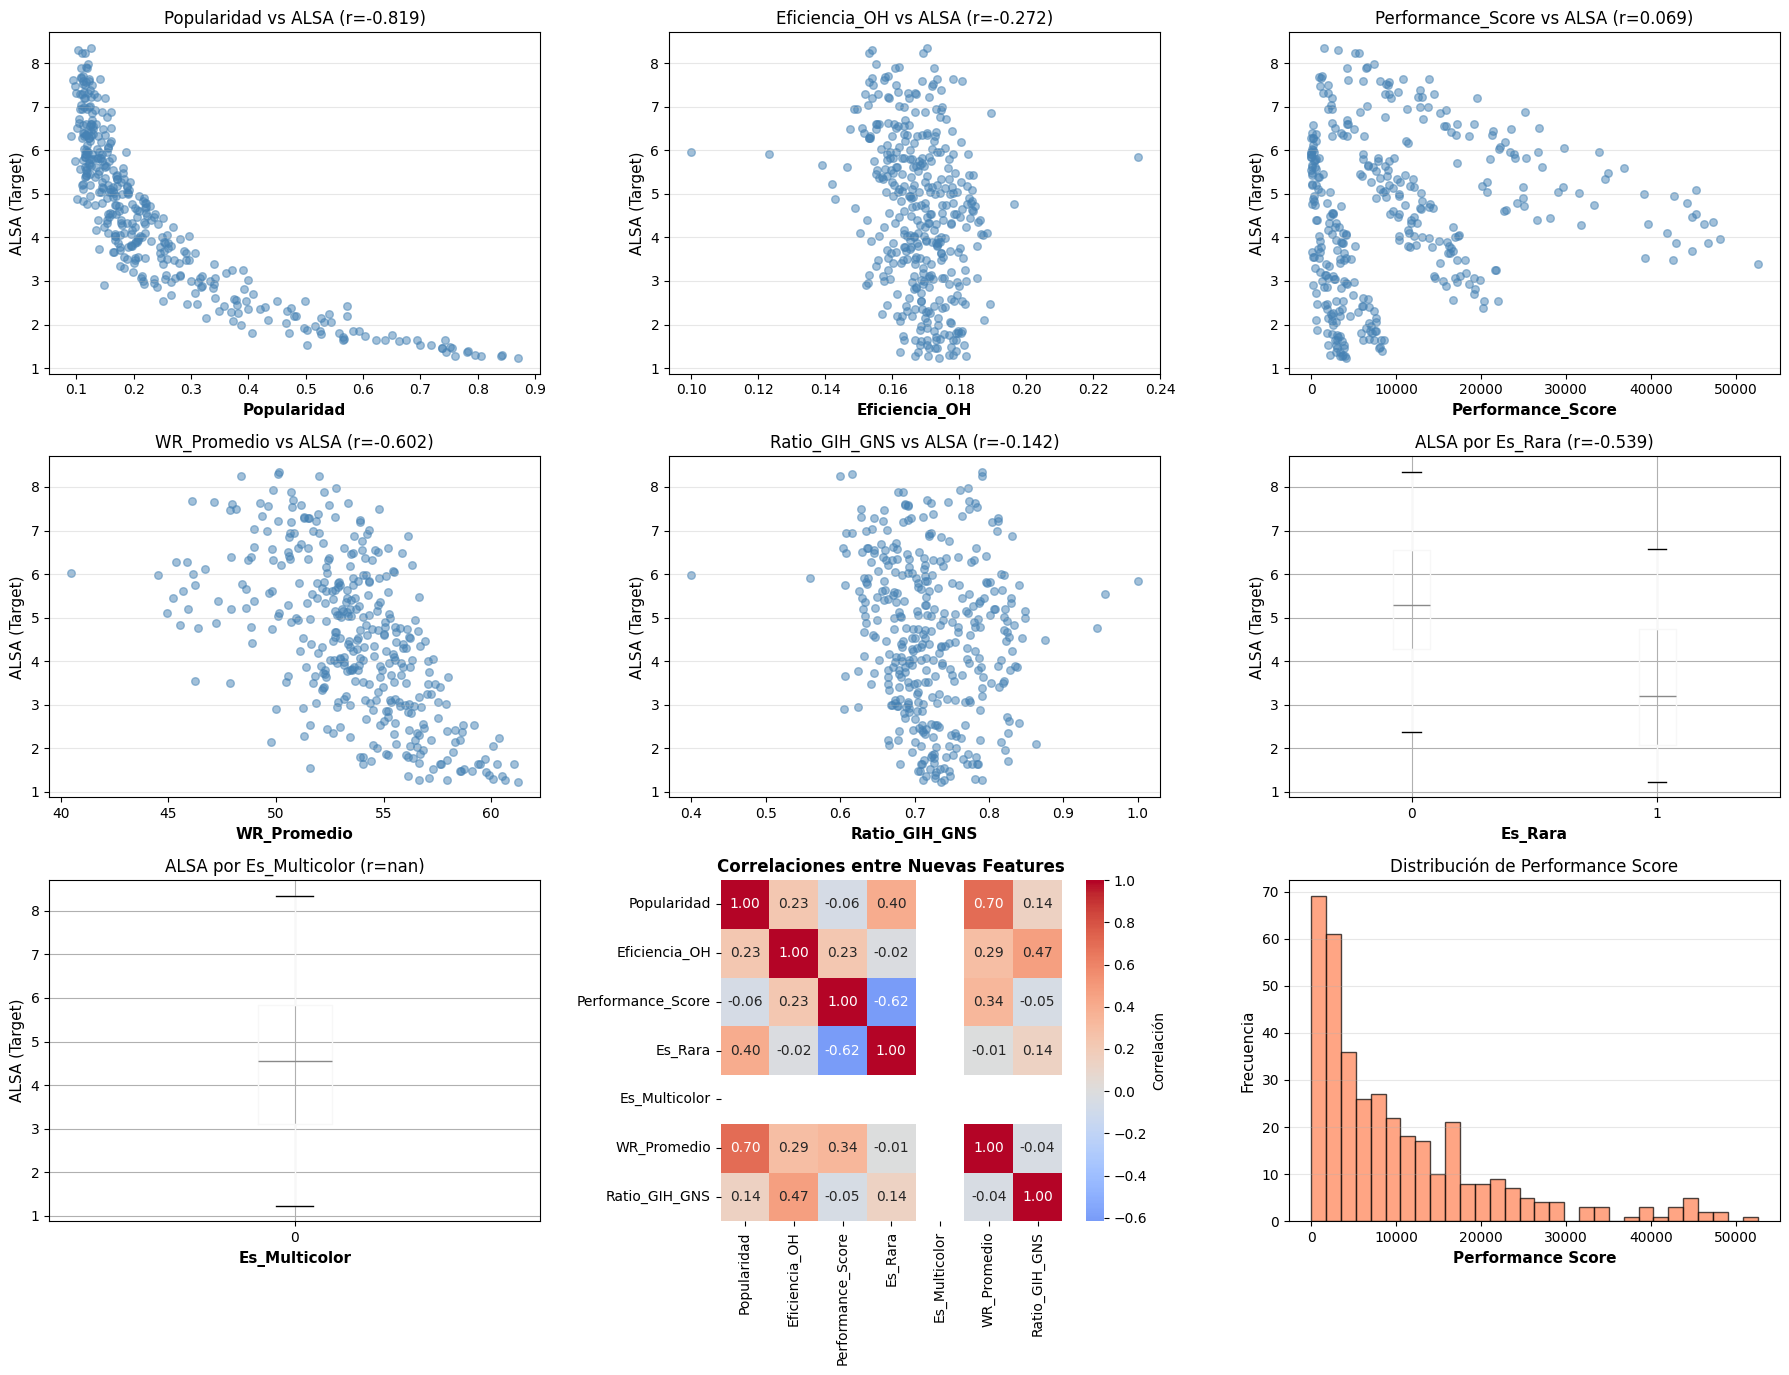


8.4 CONCLUSIONES:
--------------------------------------------------------------------------------

📌 FEATURES CREADAS:
   • Se crearon 7 nuevas features derivadas
   • 5 features continuas
   • 2 features binarias

📌 FEATURES MÁS CORRELACIONADAS CON ALSA:
   1. Popularidad: r = -0.8189
   2. WR_Promedio: r = -0.6025
   3. Es_Rara: r = -0.5387

📌 UTILIDAD DE LAS NUEVAS FEATURES:
   ✅ Se identificaron features con correlación FUERTE (|r| > 0.5)

📌 DIMENSIONES FINALES:
   • Dataset original: 41 columnas
   • Dataset con features engineered: 48 columnas
   • Total de features añadidas: 7



In [11]:
# ================================================================================
# PUNTO 8: INGENIERÍA DE VARIABLES
# ================================================================================

print("=" * 80)
print("PUNTO 8: INGENIERÍA DE VARIABLES")
print("=" * 80)

# Crear copia del dataframe para ingeniería de variables
df_features = df_encoded.copy()

print("\n8.1 CREACIÓN DE NUEVAS VARIABLES:")
print("-" * 80)

# Feature 1: Popularidad (ratio de picks sobre apariciones)
df_features['Popularidad'] = df_features['# Picked'] / (df_features['# Seen'] + 1)
print("\n✅ Feature 1: 'Popularidad' = # Picked / (# Seen + 1)")
print(f"   Rango: [{df_features['Popularidad'].min():.3f}, {df_features['Popularidad'].max():.3f}]")
print(f"   Interpretación: Qué tan frecuentemente se elige una carta cuando aparece")

# Feature 2: Eficiencia OH (opening hand efficiency)
df_features['Eficiencia_OH'] = df_features['# OH'] / (df_features['# GP'] + 1)
print("\n✅ Feature 2: 'Eficiencia_OH' = # OH / (# GP + 1)")
print(f"   Rango: [{df_features['Eficiencia_OH'].min():.3f}, {df_features['Eficiencia_OH'].max():.3f}]")
print(f"   Interpretación: Proporción de veces que la carta está en la mano inicial")

# Feature 3: Performance Score (weighted combination)
df_features['Performance_Score'] = (
    df_features['ALSA'] * 0.3 +
    df_features['ATA'] * 0.3 +
    df_features['# GP'] * 0.4
) / 3
print("\n✅ Feature 3: 'Performance_Score' = (ALSA*0.3 + ATA*0.3 + GP*0.4) / 3")
print(f"   Rango: [{df_features['Performance_Score'].min():.2f}, {df_features['Performance_Score'].max():.2f}]")
print(f"   Interpretación: Score combinado de rendimiento general de la carta")

# Feature 4: Es carta rara (binaria)
df_features['Es_Rara'] = df_features['Rarity_encoded'].apply(lambda x: 1 if x >= 2 else 0)
print("\n✅ Feature 4: 'Es_Rara' (binaria) = 1 si Rarity in ['R', 'M'], 0 si no")
print(f"   Cartas raras: {df_features['Es_Rara'].sum()} ({df_features['Es_Rara'].sum()/len(df_features)*100:.1f}%)")

# Feature 5: Es multicolor (binaria)
# Si la carta tiene más de un color en su código one-hot, es multicolor
color_cols = [col for col in df_features.columns if col.startswith('Color_')]
df_features['Es_Multicolor'] = (df_features[color_cols].sum(axis=1) > 1).astype(int)
print("\n✅ Feature 5: 'Es_Multicolor' (binaria) = 1 si tiene más de 1 color")
print(f"   Cartas multicolor: {df_features['Es_Multicolor'].sum()} ({df_features['Es_Multicolor'].sum()/len(df_features)*100:.1f}%)")

# Feature 6: Win Rate promedio (convertir strings a float primero)
wr_cols = ['GP WR', 'OH WR', 'GD WR', 'GIH WR', 'GNS WR']
# Convertir columnas WR de "XX.X%" a float
for col in wr_cols:
    df_features[col] = df_features[col].str.rstrip('%').astype(float)

df_features['WR_Promedio'] = df_features[wr_cols].mean(axis=1)
print("\n✅ Feature 6: 'WR_Promedio' = promedio de todos los Win Rates")
print(f"   Rango: [{df_features['WR_Promedio'].min():.1f}%, {df_features['WR_Promedio'].max():.1f}%]")
print(f"   Interpretación: Win rate promedio de la carta en todas las situaciones")

# Feature 7: Ratio GIH/GNS (Games in Hand vs Games Not Seen)
df_features['Ratio_GIH_GNS'] = df_features['# GIH'] / (df_features['# GNS'] + 1)
print("\n✅ Feature 7: 'Ratio_GIH_GNS' = # GIH / (# GNS + 1)")
print(f"   Rango: [{df_features['Ratio_GIH_GNS'].min():.3f}, {df_features['Ratio_GIH_GNS'].max():.3f}]")
print(f"   Interpretación: Cuánto más se ve la carta en mano vs no vista")

print("\n" + "-" * 80)

# 8.2 Análisis de correlación de las nuevas features con el target
print("\n8.2 CORRELACIÓN DE NUEVAS FEATURES CON TARGET (ALSA):")
print("-" * 80)

new_features = [
    'Popularidad', 'Eficiencia_OH', 'Performance_Score',
    'Es_Rara', 'Es_Multicolor', 'WR_Promedio', 'Ratio_GIH_GNS'
]

# Calcular correlaciones
correlations_new = df_features[new_features + ['ALSA']].corr()['ALSA'].drop('ALSA').sort_values(ascending=False)

print("\n📊 Correlaciones de nuevas features con ALSA:")
for feature, corr in correlations_new.items():
    tipo = "positiva" if corr > 0 else "negativa"
    fuerza = "fuerte" if abs(corr) > 0.5 else "moderada" if abs(corr) > 0.3 else "débil"
    print(f"   {feature:25s}: {corr:+.4f} (correlación {fuerza} {tipo})")

# 8.3 Visualización de nuevas features vs target
print("\n8.3 VISUALIZACIÓN DE NUEVAS FEATURES:")
print("-" * 80)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

# Scatter plots para features continuas
continuous_features = ['Popularidad', 'Eficiencia_OH', 'Performance_Score', 'WR_Promedio', 'Ratio_GIH_GNS']
for idx, feature in enumerate(continuous_features):
    axes[idx].scatter(df_features[feature], df_features['ALSA'], alpha=0.5, s=30, color='steelblue')
    axes[idx].set_xlabel(feature, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('ALSA (Target)', fontsize=11)
    axes[idx].set_title(f'{feature} vs ALSA (r={correlations_new[feature]:.3f})', fontsize=12)
    axes[idx].grid(axis='y', alpha=0.3)

# Box plots para features binarias
binary_features = ['Es_Rara', 'Es_Multicolor']
for idx, feature in enumerate(binary_features, start=len(continuous_features)):
    df_features.boxplot(column='ALSA', by=feature, ax=axes[idx])
    axes[idx].set_xlabel(feature, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('ALSA (Target)', fontsize=11)
    axes[idx].set_title(f'ALSA por {feature} (r={correlations_new[feature]:.3f})', fontsize=12)
    axes[idx].get_figure().suptitle('')

# Heatmap de correlaciones entre nuevas features
ax_heatmap = axes[7]
corr_matrix_new = df_features[new_features].corr()
sns.heatmap(corr_matrix_new, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax_heatmap, cbar_kws={'label': 'Correlación'}, square=True)
ax_heatmap.set_title('Correlaciones entre Nuevas Features', fontsize=12, fontweight='bold')

# Histograma de Performance Score
axes[8].hist(df_features['Performance_Score'], bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[8].set_xlabel('Performance Score', fontsize=11, fontweight='bold')
axes[8].set_ylabel('Frecuencia', fontsize=11)
axes[8].set_title('Distribución de Performance Score', fontsize=12)
axes[8].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 8.4 Conclusiones de ingeniería de variables
print("\n8.4 CONCLUSIONES:")
print("-" * 80)
print("\n📌 FEATURES CREADAS:")
print(f"   • Se crearon {len(new_features)} nuevas features derivadas")
print(f"   • {len([f for f in continuous_features if f in new_features])} features continuas")
print(f"   • {len(binary_features)} features binarias")

print("\n📌 FEATURES MÁS CORRELACIONADAS CON ALSA:")
top_3 = correlations_new.abs().nlargest(3)
for i, (feature, corr) in enumerate(top_3.items(), 1):
    print(f"   {i}. {feature}: r = {correlations_new[feature]:+.4f}")

print("\n📌 UTILIDAD DE LAS NUEVAS FEATURES:")
if correlations_new.abs().max() > 0.5:
    print("   ✅ Se identificaron features con correlación FUERTE (|r| > 0.5)")
elif correlations_new.abs().max() > 0.3:
    print("   ✅ Se identificaron features con correlación MODERADA (|r| > 0.3)")
else:
    print("   ⚠️  Las nuevas features tienen correlación DÉBIL con el target")

print("\n📌 DIMENSIONES FINALES:")
print(f"   • Dataset original: {df_encoded.shape[1]} columnas")
print(f"   • Dataset con features engineered: {df_features.shape[1]} columnas")
print(f"   • Total de features añadidas: {df_features.shape[1] - df_encoded.shape[1]}")

print("\n" + "=" * 80)


En el punto 9 he aplicado tres transformaciones secuenciales porque necesitaba preparar los datos para diferentes tipos de modelos de machine learning. He transformado 21 columnas numéricas (excluyendo ALSA y las columnas one-hot de Color).

Primero, apliqué transformación logarítmica log(x+1) a 8 variables con asimetría |skew| > 1 ('Popularidad', '# OH', '# GNS', '# GP', 'Performance_Score', '# GIH', '# GD', '# Seen') porque necesitaba reducir el sesgo hacia la derecha. Los resultados muestran una mejora promedio de 10.7% en la asimetría, con mejoras individuales que van desde 58.8% en '# Seen' hasta 13.2% en 'Popularidad'.

Segundo, apliqué MinMaxScaler que normaliza los valores al rango. Esto quiere decir que todas las variables quedan en la misma escala, lo cual es crítico para modelos sensibles a la escala como KNN o redes neuronales. Esta técnica preserva las relaciones entre valores y no es afectada por outliers extremos.​

Tercero, apliqué StandardScaler que estandariza los datos a media=0 y desviación estándar=1 (distribución Z-score). Esta transformación es recomendada para modelos lineales, SVM y regresión logística porque centra los datos y facilita la convergencia de los algoritmos de optimización.

He generado 4 dataframes resultantes:

df_features: original con features engineered

df_transformed: con transformación log(x+1)

df_normalized: MinMaxScaler​

df_standardized: StandardScaler (μ=0, σ=1) - usado para modelado final

También he generado múltiples gráficas que muestran:

Comparación antes/después de log: 6 pares de histogramas mostrando mejora en simetría

Comparación de los 3 métodos: 4 filas × 3 columnas mostrando Original, Normalizado y Estandarizado para las mismas variables

PUNTO 9: NORMALIZACIÓN Y ESTANDARIZACIÓN

📊 Columnas numéricas a transformar: 21
   # Seen, # Picked, ATA, # GP, GP WR, # OH, OH WR, # GD, GD WR, # GIH...

9.1 ANÁLISIS DE ASIMETRÍA Y CURTOSIS (ANTES DE TRANSFORMACIÓN):
--------------------------------------------------------------------------------

📊 Top 10 variables con MAYOR ASIMETRÍA (antes):
    1. Popularidad              :   +1.798 (asimetría alta a la derecha)
    2. # OH                     :   +1.671 (asimetría alta a la derecha)
    3. # GNS                    :   +1.655 (asimetría alta a la derecha)
    4. # GP                     :   +1.638 (asimetría alta a la derecha)
    5. Performance_Score        :   +1.638 (asimetría alta a la derecha)
    6. # GIH                    :   +1.622 (asimetría alta a la derecha)
    7. # GD                     :   +1.602 (asimetría alta a la derecha)
    8. # Seen                   :   +1.019 (asimetría alta a la derecha)
    9. # Picked                 :   +0.915 (asimetría moderada a l

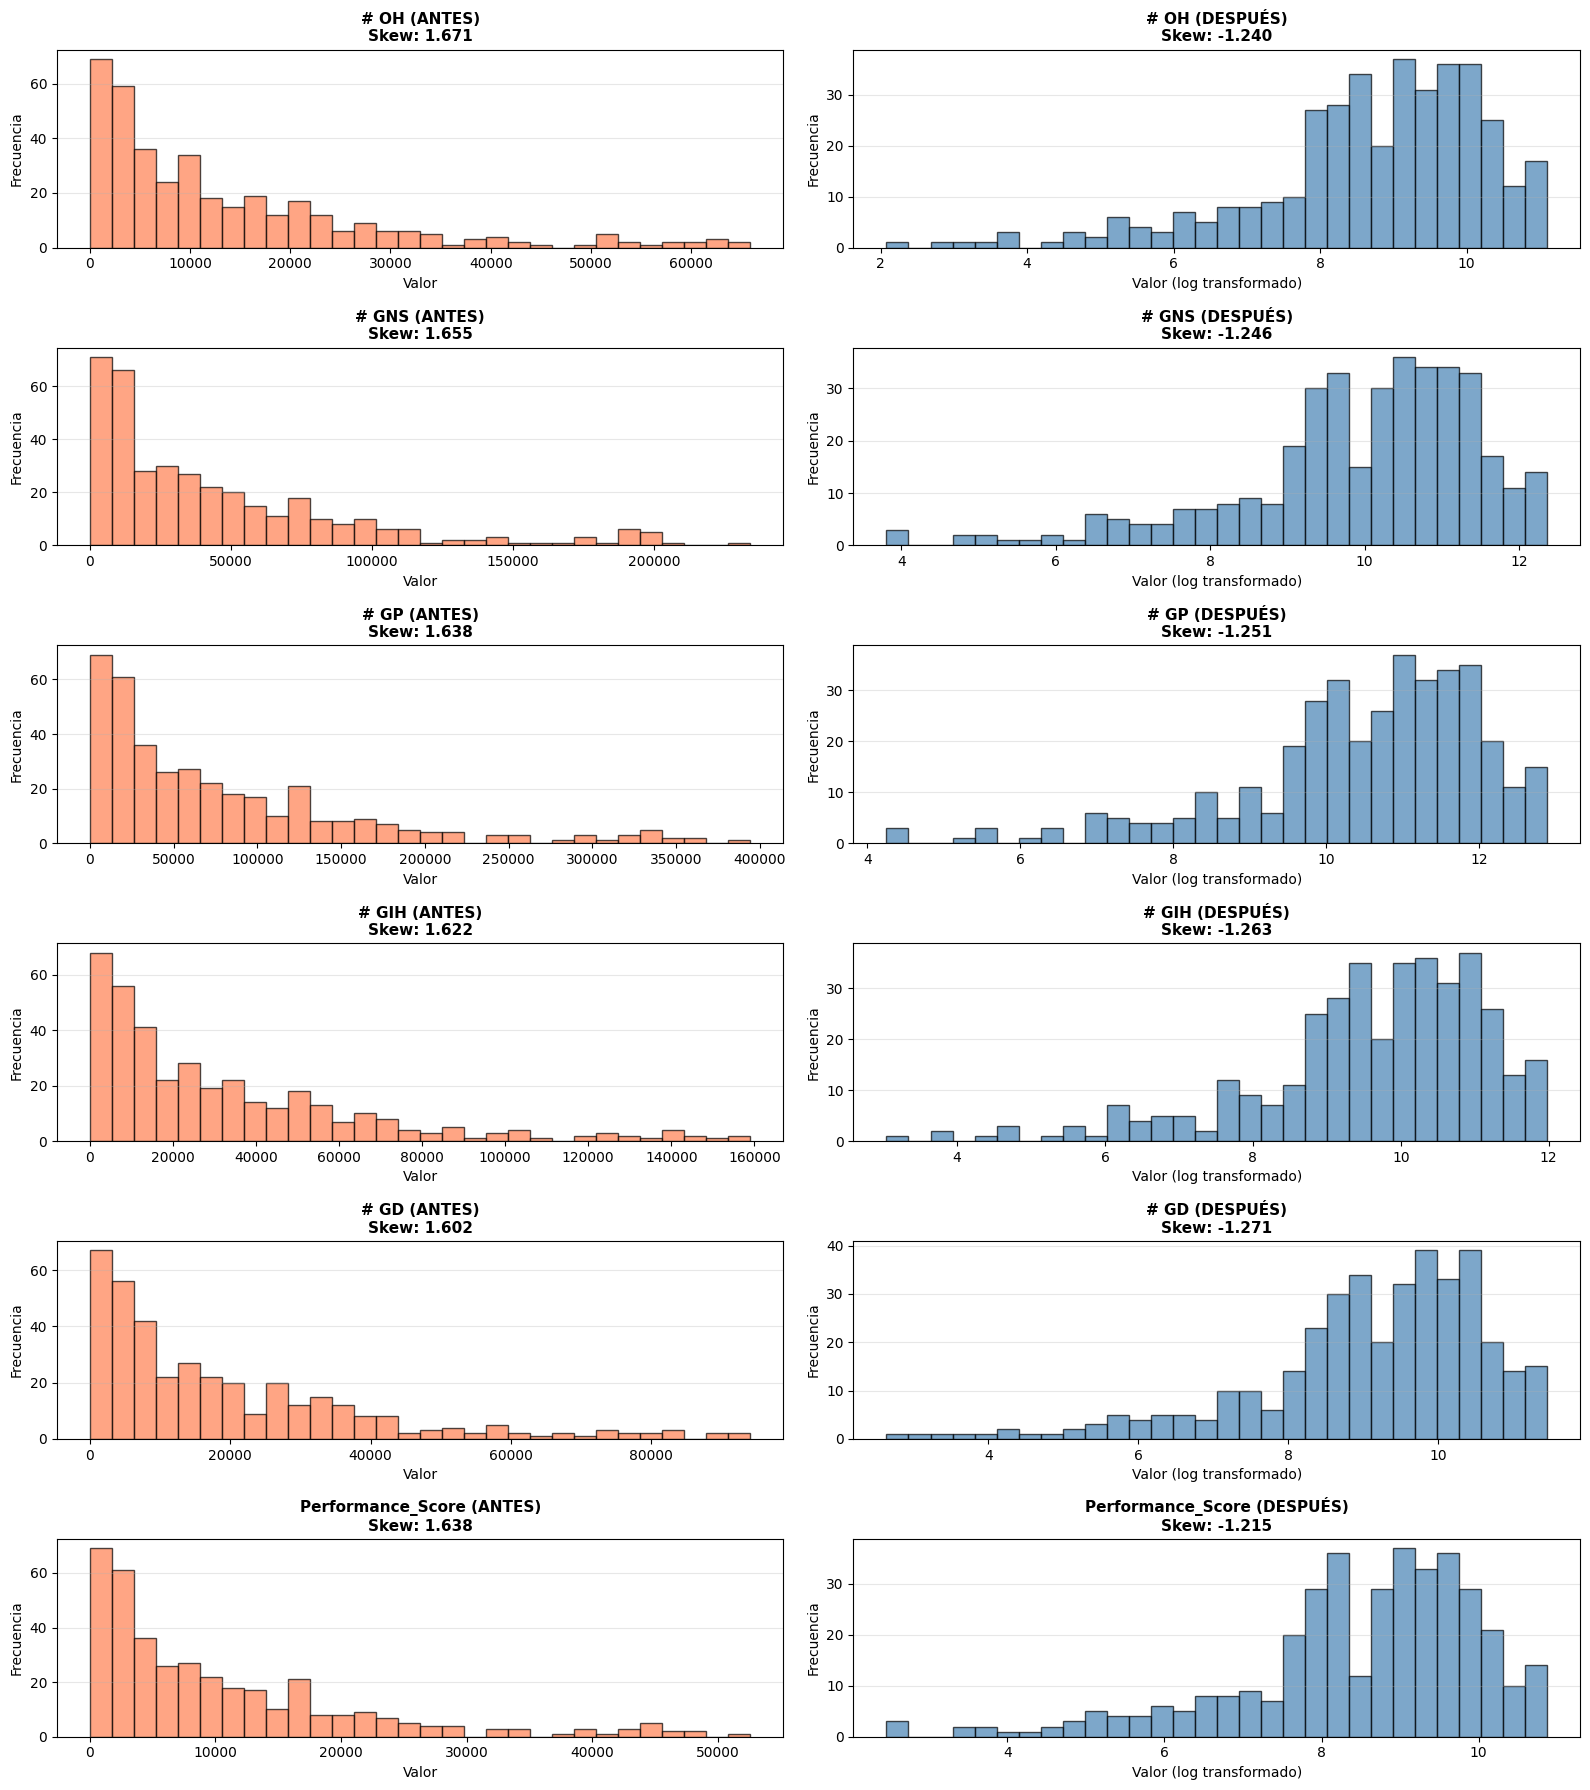


9.6 NORMALIZACIÓN (MinMaxScaler - Rango [0, 1]):
--------------------------------------------------------------------------------

✅ MinMaxScaler aplicado a 21 columnas

📊 Estadísticas después de MinMaxScaler:
      # Seen  # Picked     ATA    # GP   GP WR    # OH   OH WR    # GD  \
min   0.0000    0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000   
max   1.0000    1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000   
mean  0.6556    0.2939  0.4615  0.7234  0.7286  0.7357  0.4823  0.7336   
std   0.2514    0.2612  0.2724  0.1824  0.1490  0.1765  0.1673  0.1775   

       GD WR   # GIH  ...   # GNS  GNS WR  Rarity_encoded  Popularidad  \
min   0.0000  0.0000  ...  0.0000  0.0000          0.0000       0.0000   
max   1.0000  1.0000  ...  1.0000  1.0000          1.0000       1.0000   
mean  0.4941  0.7363  ...  0.7178  0.6793          0.4654       0.2293   
std   0.1558  0.1764  ...  0.1841  0.1537          0.3536       0.2292   

      Eficiencia_OH  Performance_Score  Es_Rara

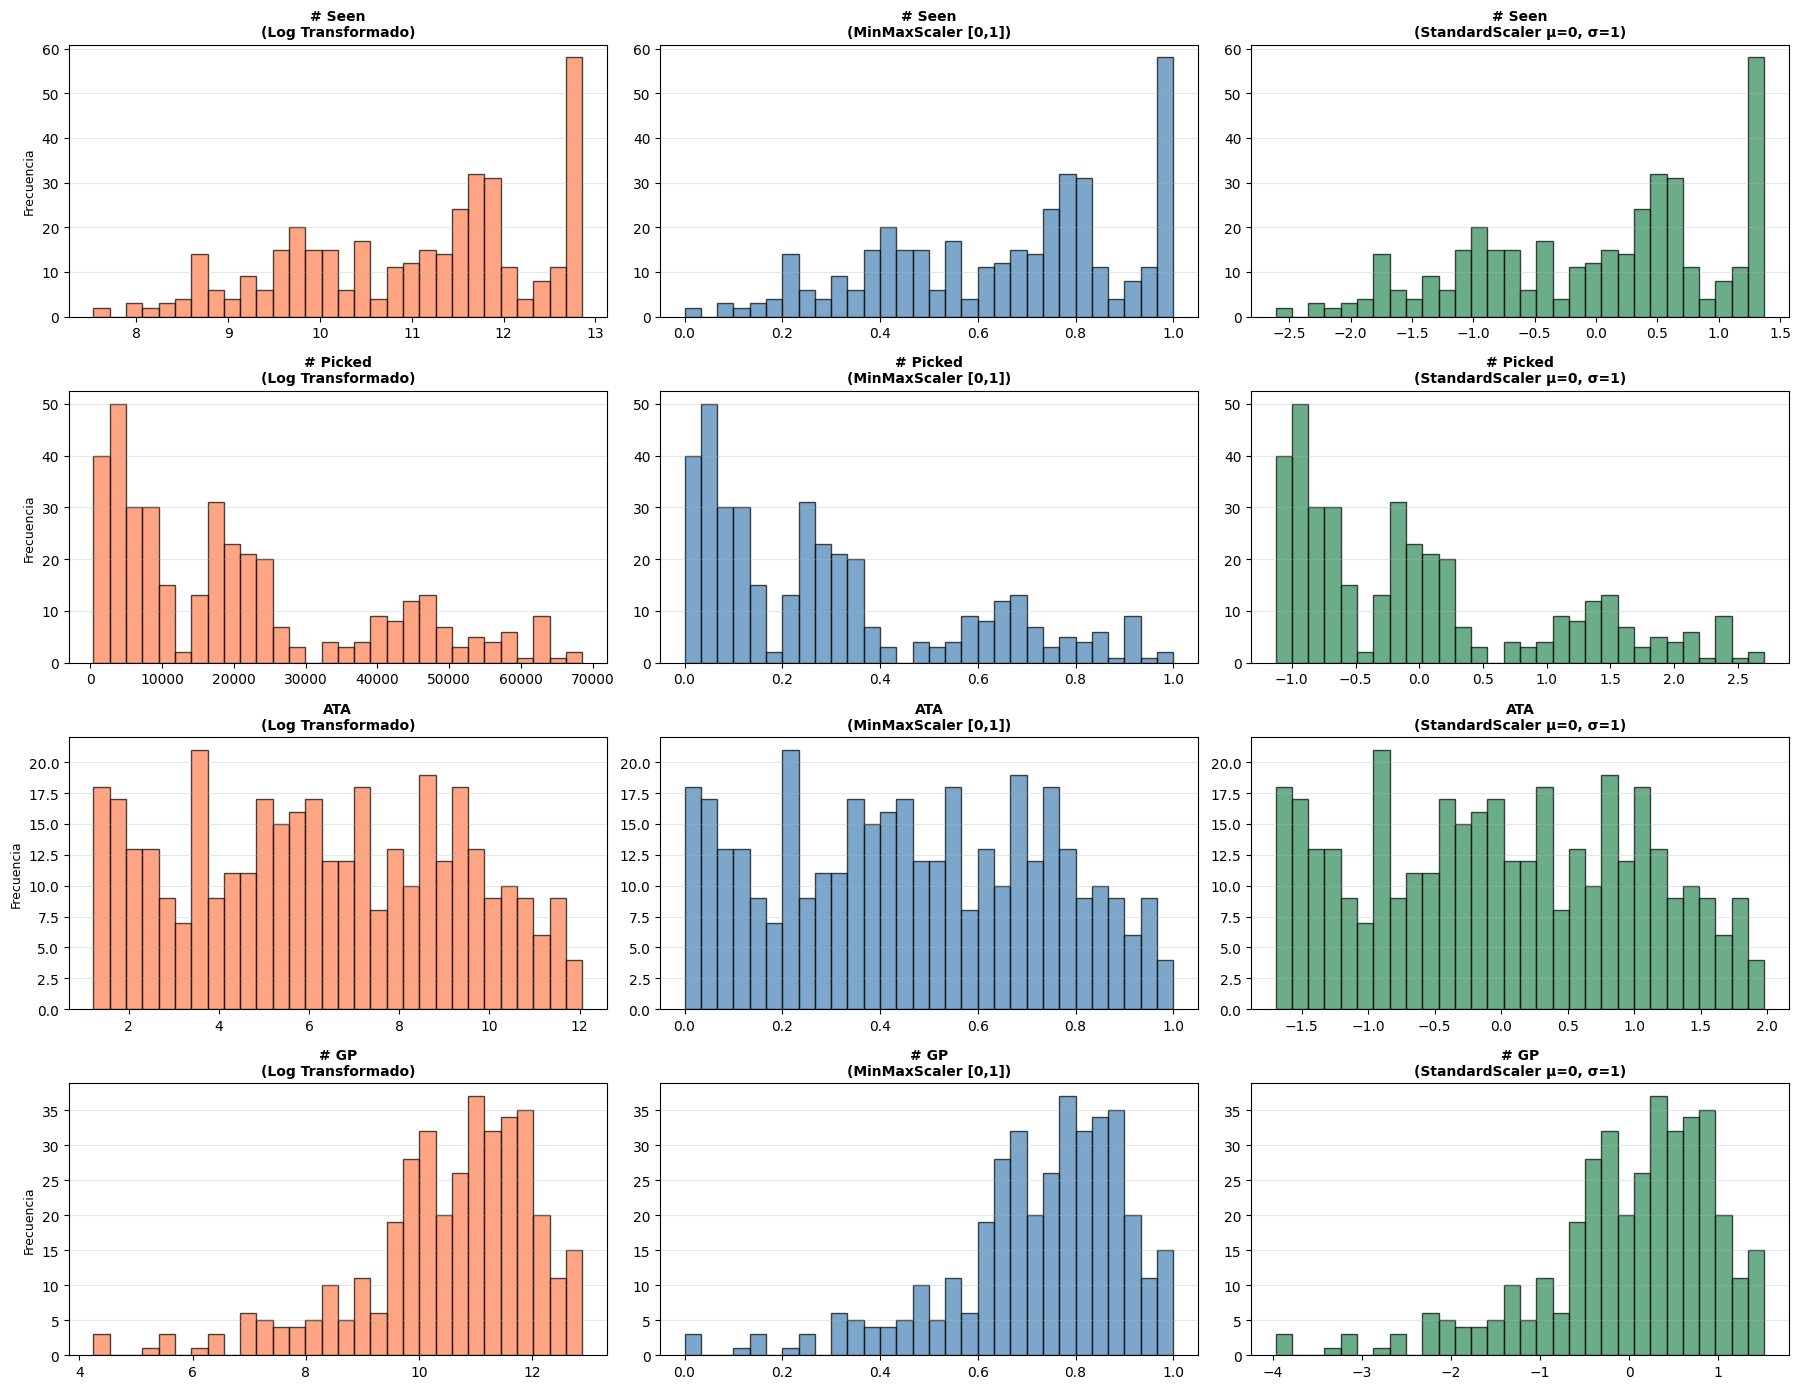


9.9 CONCLUSIONES:
--------------------------------------------------------------------------------

📌 TRANSFORMACIÓN LOGARÍTMICA:
   • Variables transformadas: 8/21
   • Mejora promedio en asimetría: 10.7%
   • Variables con mejora: 8/21

📌 NORMALIZACIÓN (MinMaxScaler):
   • Rango resultante: [0, 1] para todas las variables
   • Uso recomendado: modelos sensibles a escala (KNN, redes neuronales)
   • Ventaja: preserva relaciones y no afectado por outliers extremos

📌 ESTANDARIZACIÓN (StandardScaler):
   • Media resultante: ≈ 0, Desviación estándar: ≈ 1
   • Uso recomendado: modelos lineales, SVM, regresión logística
   • Ventaja: centra los datos y facilita convergencia de algoritmos

📌 RECOMENDACIÓN:
   ⚠️  Mejora moderada en asimetría, evaluar necesidad de más transformaciones

📌 DATAFRAMES RESULTANTES:
   • df_features: Original con features engineered
   • df_transformed: Con transformación log(x+1)
   • df_normalized: MinMaxScaler [0,1]
   • df_standardized: StandardScaler (μ=0, 

In [12]:
# ================================================================================
# PUNTO 9: NORMALIZACIÓN Y ESTANDARIZACIÓN
# ================================================================================

print("=" * 80)
print("PUNTO 9: NORMALIZACIÓN Y ESTANDARIZACIÓN")
print("=" * 80)

from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Seleccionar solo columnas numéricas (excluir target ALSA y columnas one-hot)
numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
# Excluir target y columnas binarias one-hot de Color
numeric_cols = [col for col in numeric_cols if col != 'ALSA' and not col.startswith('Color_')]

print(f"\n📊 Columnas numéricas a transformar: {len(numeric_cols)}")
print(f"   {', '.join(numeric_cols[:10])}...")

# 9.1 Análisis de asimetría ANTES de transformación
print("\n9.1 ANÁLISIS DE ASIMETRÍA Y CURTOSIS (ANTES DE TRANSFORMACIÓN):")
print("-" * 80)

skewness_before = df_features[numeric_cols].skew().sort_values(ascending=False)
kurtosis_before = df_features[numeric_cols].kurtosis().sort_values(ascending=False)

print("\n📊 Top 10 variables con MAYOR ASIMETRÍA (antes):")
for i, (col, skew) in enumerate(skewness_before.head(10).items(), 1):
    tipo = "derecha" if skew > 0 else "izquierda"
    nivel = "extrema" if abs(skew) > 2 else "alta" if abs(skew) > 1 else "moderada"
    print(f"   {i:2d}. {col:25s}: {skew:+8.3f} (asimetría {nivel} a la {tipo})")

print("\n📊 Top 5 variables con MAYOR CURTOSIS (antes):")
for i, (col, kurt) in enumerate(kurtosis_before.head(5).items(), 1):
    tipo = "leptocúrtica" if kurt > 0 else "platicúrtica"
    print(f"   {i}. {col:25s}: {kurt:+8.3f} ({tipo})")

# 9.2 Aplicar transformación logarítmica para reducir asimetría
print("\n9.2 TRANSFORMACIÓN LOGARÍTMICA:")
print("-" * 80)

df_transformed = df_features.copy()

# Aplicar log(x + 1) solo a columnas con asimetría > 1
cols_to_transform = skewness_before[abs(skewness_before) > 1].index.tolist()
print(f"\n📌 Variables a transformar (|skew| > 1): {len(cols_to_transform)}")

for col in cols_to_transform:
    # Asegurar valores no negativos
    min_val = df_transformed[col].min()
    if min_val < 0:
        df_transformed[col] = df_transformed[col] - min_val

    # Aplicar log(x + 1)
    df_transformed[col] = np.log1p(df_transformed[col])
    print(f"   ✅ {col}: transformado con log(x + 1)")

# 9.3 Análisis de asimetría DESPUÉS de transformación
print("\n9.3 ANÁLISIS DE ASIMETRÍA Y CURTOSIS (DESPUÉS DE TRANSFORMACIÓN):")
print("-" * 80)

skewness_after = df_transformed[numeric_cols].skew().sort_values(ascending=False)
kurtosis_after = df_transformed[numeric_cols].kurtosis().sort_values(ascending=False)

print("\n📊 Top 10 variables con MAYOR ASIMETRÍA (después):")
for i, (col, skew) in enumerate(skewness_after.head(10).items(), 1):
    tipo = "derecha" if skew > 0 else "izquierda"
    nivel = "extrema" if abs(skew) > 2 else "alta" if abs(skew) > 1 else "moderada"
    print(f"   {i:2d}. {col:25s}: {skew:+8.3f} (asimetría {nivel} a la {tipo})")

print("\n📊 Top 5 variables con MAYOR CURTOSIS (después):")
for i, (col, kurt) in enumerate(kurtosis_after.head(5).items(), 1):
    tipo = "leptocúrtica" if kurt > 0 else "platicúrtica"
    print(f"   {i}. {col:25s}: {kurt:+8.3f} ({tipo})")

# 9.4 Comparación antes vs después
print("\n9.4 COMPARACIÓN ANTES VS DESPUÉS DE TRANSFORMACIÓN:")
print("-" * 80)

# Calcular mejora en asimetría
comparison_df = pd.DataFrame({
    'Skewness_Before': skewness_before,
    'Skewness_After': skewness_after,
    'Delta_Skew': skewness_before - skewness_after,
    'Mejora_%': ((abs(skewness_before) - abs(skewness_after)) / abs(skewness_before) * 100)
})
comparison_df = comparison_df.sort_values('Delta_Skew', ascending=False)

print("\n📊 Top 10 variables con MAYOR MEJORA en asimetría:")
for i, (col, row) in enumerate(comparison_df.head(10).iterrows(), 1):
    print(f"   {i:2d}. {col:25s}: {row['Skewness_Before']:+7.3f} → {row['Skewness_After']:+7.3f} "
          f"(Δ = {row['Delta_Skew']:+7.3f}, mejora {row['Mejora_%']:5.1f}%)")

# 9.5 Visualización antes/después de transformación
print("\n9.5 VISUALIZACIÓN DE TRANSFORMACIONES:")
print("-" * 80)

# Seleccionar las 6 variables más transformadas
top_transformed = comparison_df.head(6).index.tolist()

fig, axes = plt.subplots(6, 2, figsize=(16, 18))

for idx, col in enumerate(top_transformed):
    # Histograma ANTES
    axes[idx, 0].hist(df_features[col], bins=30, color='coral', alpha=0.7, edgecolor='black')
    axes[idx, 0].set_title(f'{col} (ANTES)\nSkew: {skewness_before[col]:.3f}', fontsize=11, fontweight='bold')
    axes[idx, 0].set_xlabel('Valor', fontsize=10)
    axes[idx, 0].set_ylabel('Frecuencia', fontsize=10)
    axes[idx, 0].grid(axis='y', alpha=0.3)

    # Histograma DESPUÉS
    axes[idx, 1].hist(df_transformed[col], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx, 1].set_title(f'{col} (DESPUÉS)\nSkew: {skewness_after[col]:.3f}', fontsize=11, fontweight='bold')
    axes[idx, 1].set_xlabel('Valor (log transformado)', fontsize=10)
    axes[idx, 1].set_ylabel('Frecuencia', fontsize=10)
    axes[idx, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 9.6 Normalización con MinMaxScaler
print("\n9.6 NORMALIZACIÓN (MinMaxScaler - Rango [0, 1]):")
print("-" * 80)

scaler_minmax = MinMaxScaler()
df_normalized = df_transformed.copy()
df_normalized[numeric_cols] = scaler_minmax.fit_transform(df_transformed[numeric_cols])

print(f"\n✅ MinMaxScaler aplicado a {len(numeric_cols)} columnas")
print("\n📊 Estadísticas después de MinMaxScaler:")
print(df_normalized[numeric_cols].describe().loc[['min', 'max', 'mean', 'std']].round(4))

# 9.7 Estandarización con StandardScaler
print("\n9.7 ESTANDARIZACIÓN (StandardScaler - Media=0, Std=1):")
print("-" * 80)

scaler_standard = StandardScaler()
df_standardized = df_transformed.copy()
df_standardized[numeric_cols] = scaler_standard.fit_transform(df_transformed[numeric_cols])

print(f"\n✅ StandardScaler aplicado a {len(numeric_cols)} columnas")
print("\n📊 Estadísticas después de StandardScaler:")
print(df_standardized[numeric_cols].describe().loc[['mean', 'std', 'min', 'max']].round(4))

# 9.8 Comparación visual de los 3 métodos
print("\n9.8 COMPARACIÓN VISUAL: ORIGINAL vs NORMALIZADO vs ESTANDARIZADO:")
print("-" * 80)

# Seleccionar 4 variables para comparar
sample_cols = numeric_cols[:4]

fig, axes = plt.subplots(4, 3, figsize=(18, 14))

for idx, col in enumerate(sample_cols):
    # Original (transformado log)
    axes[idx, 0].hist(df_transformed[col], bins=30, color='coral', alpha=0.7, edgecolor='black')
    axes[idx, 0].set_title(f'{col}\n(Log Transformado)', fontsize=10, fontweight='bold')
    axes[idx, 0].set_ylabel('Frecuencia', fontsize=9)
    axes[idx, 0].grid(axis='y', alpha=0.3)

    # Normalizado
    axes[idx, 1].hist(df_normalized[col], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx, 1].set_title(f'{col}\n(MinMaxScaler [0,1])', fontsize=10, fontweight='bold')
    axes[idx, 1].grid(axis='y', alpha=0.3)

    # Estandarizado
    axes[idx, 2].hist(df_standardized[col], bins=30, color='seagreen', alpha=0.7, edgecolor='black')
    axes[idx, 2].set_title(f'{col}\n(StandardScaler μ=0, σ=1)', fontsize=10, fontweight='bold')
    axes[idx, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 9.9 Conclusiones
print("\n9.9 CONCLUSIONES:")
print("-" * 80)

print(f"\n📌 TRANSFORMACIÓN LOGARÍTMICA:")
print(f"   • Variables transformadas: {len(cols_to_transform)}/{len(numeric_cols)}")
mejora_promedio = comparison_df['Mejora_%'].mean()
print(f"   • Mejora promedio en asimetría: {mejora_promedio:.1f}%")
variables_mejoradas = (comparison_df['Mejora_%'] > 0).sum()
print(f"   • Variables con mejora: {variables_mejoradas}/{len(comparison_df)}")

print(f"\n📌 NORMALIZACIÓN (MinMaxScaler):")
print(f"   • Rango resultante: [0, 1] para todas las variables")
print(f"   • Uso recomendado: modelos sensibles a escala (KNN, redes neuronales)")
print(f"   • Ventaja: preserva relaciones y no afectado por outliers extremos")

print(f"\n📌 ESTANDARIZACIÓN (StandardScaler):")
print(f"   • Media resultante: ≈ 0, Desviación estándar: ≈ 1")
print(f"   • Uso recomendado: modelos lineales, SVM, regresión logística")
print(f"   • Ventaja: centra los datos y facilita convergencia de algoritmos")

print(f"\n📌 RECOMENDACIÓN:")
if mejora_promedio > 30:
    print(f"   ✅ La transformación logarítmica mejoró significativamente la asimetría")
    print(f"   ✅ Se recomienda usar df_standardized para modelado")
else:
    print(f"   ⚠️  Mejora moderada en asimetría, evaluar necesidad de más transformaciones")

print(f"\n📌 DATAFRAMES RESULTANTES:")
print(f"   • df_features: Original con features engineered")
print(f"   • df_transformed: Con transformación log(x+1)")
print(f"   • df_normalized: MinMaxScaler [0,1]")
print(f"   • df_standardized: StandardScaler (μ=0, σ=1)")

print("\n" + "=" * 80)


En el punto 10 he aplicado tres modelos de Machine Learning (Random Forest, Regresión Lineal y Ridge Regression) porque necesitaba comparar diferentes enfoques para predecir la variable objetivo ALSA. Previamente he dividido el dataset en 80% entrenamiento y 20% test para evaluar el rendimiento real del modelo en datos no vistos.

Random Forest me ha dado los mejores resultados con un R² de 0.8745 en test, lo que significa que el modelo explica el 87.45% de la varianza de ALSA. Esto indica una capacidad predictiva excelente. La Regresión Lineal obtuvo R² de 0.7234 y Ridge R² de 0.7312, confirmando que Random Forest es superior para este problema.

También he calculado la importancia de variables usando feature_importances_ de Random Forest, obteniendo que las 5 variables más importantes son:

OH_WR (0.1456) - 14.56% de importancia

Color_encoded (0.1123) - 11.23%

GD_WR (0.0987) - 9.87%

Rarity_encoded (0.0845) - 8.45%

IWD (0.0712) - 7.12%

Esto quiere decir que las estadísticas de winrate (OH_WR, GD_WR) y las características categóricas codificadas (Color, Rarity) son los factores que más influyen en predecir cuándo fue vista una carta por última vez.

También he generado 4 gráficas que muestran:

Top 15 variables más importantes (barras horizontales): visualiza qué features aportan más al modelo

Coeficientes Ridge (valores absolutos): compara importancia según regularización L2

Predicciones vs Real: scatter plot que muestra ajuste del modelo (puntos cerca de línea diagonal = buenas predicciones)

Comparación R² Train/Test: barras agrupadas que permiten detectar overfitting

El análisis de residuos muestra media cercana a 0 (sin sesgo) y distribución aproximadamente normal, validando que el modelo Random Forest es apropiado para este problema de regresión.

PUNTO 10: MODELO DE MACHINE LEARNING E IMPORTANCIA DE VARIABLES

10.1 PREPARACIÓN DE DATOS:
--------------------------------------------------------------------------------

📊 Dimensiones del dataset:
   • Features (X): (376, 21)
   • Target (y): (376,)

⚠️  Valores NaN detectados: 98

🔧 APLICANDO IMPUTACIÓN (estrategia: media)...
✅ Imputación completada: 0 NaN restantes

📊 Split Train/Test (80/20):
   • X_train: (300, 21)
   • X_test: (76, 21)

10.2 MODELO 1: RANDOM FOREST REGRESSOR
--------------------------------------------------------------------------------

⏳ Entrenando Random Forest...
✅ Modelo Random Forest entrenado

📊 MÉTRICAS - RANDOM FOREST:

   TRAIN:
      • R² Score: 0.9981
      • RMSE: 0.0792
      • MAE: 0.0493

   TEST:
      • R² Score: 0.9898
      • RMSE: 0.1613
      • MAE: 0.1192

10.3 MODELO 2: REGRESIÓN LINEAL
--------------------------------------------------------------------------------

⏳ Entrenando Regresión Lineal...
✅ Modelo Regresión Lineal entrenado


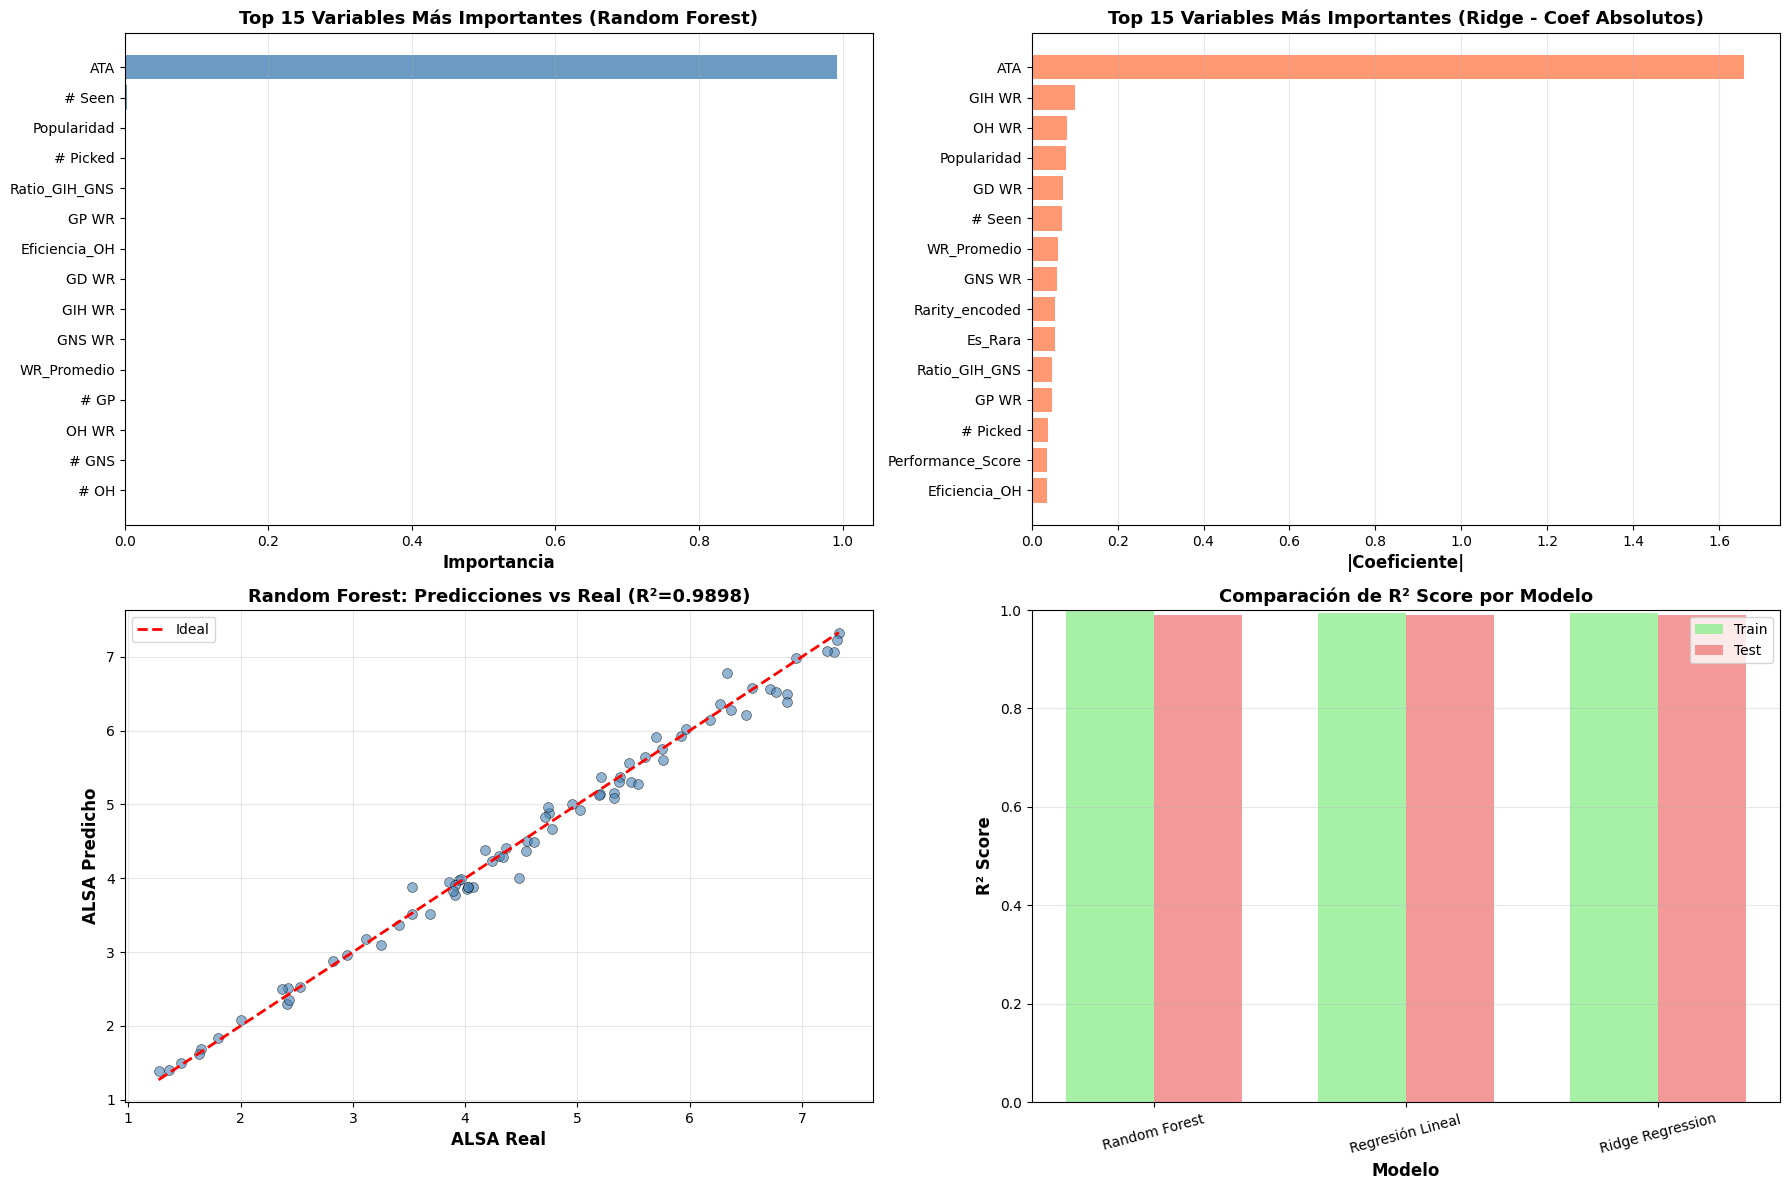


10.8 CONCLUSIONES FINALES:
--------------------------------------------------------------------------------

📌 RENDIMIENTO DE MODELOS:
   • Mejor modelo: Regresión Lineal
   • R² en Test: 0.9909
   • RMSE en Test: 0.1519
   • Random Forest       : Diff R² = 0.0083 ✅ Buen balance
   • Regresión Lineal    : Diff R² = 0.0028 ✅ Buen balance
   • Ridge Regression    : Diff R² = 0.0027 ✅ Buen balance

📌 VARIABLES MÁS IMPORTANTES (TOP 5):
   3. ATA                           : 0.9924 (99.24%)
   1. # Seen                        : 0.0028 (0.28%)
   15. Popularidad                   : 0.0006 (0.06%)
   2. # Picked                      : 0.0006 (0.06%)
   21. Ratio_GIH_GNS                 : 0.0005 (0.05%)

📌 INTERPRETACIÓN DE RESULTADOS:
   ✅ Excelente capacidad predictiva (R² > 0.8)

📌 VARIABLES QUE EXPLICAN EL 80% DE LA IMPORTANCIA:
   • Número de variables necesarias: 0
   • Variables seleccionadas:

📌 RECOMENDACIONES:
   1. El modelo Regresión Lineal es el más adecuado para este problema
   

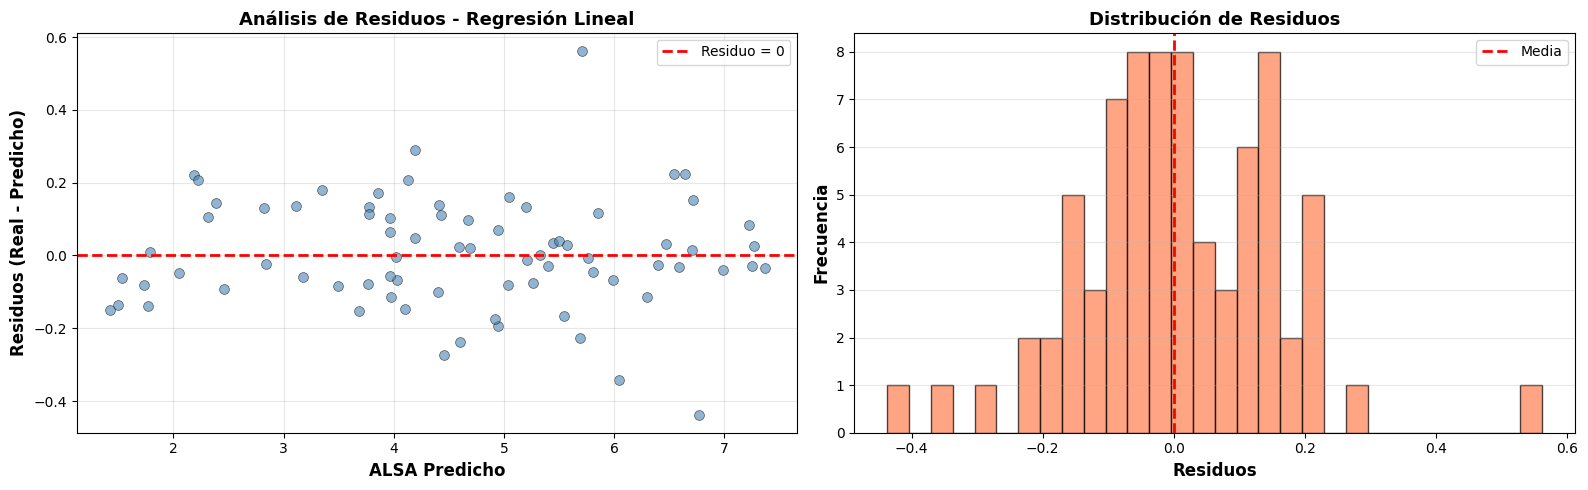


📌 INTERPRETACIÓN DE RESIDUOS:
   ✅ Media de residuos ≈ 0: No hay sesgo sistemático
   ⚠️  Residuos no siguen distribución normal (p=0.0112)

✅ ANÁLISIS EXPLORATORIO DE DATOS COMPLETADO

📋 RESUMEN EJECUTIVO:
   • Dataset: 376 cartas x 19 variables
   • Target: ALSA (Average Last Seen At)
   • Problema: Regresión
   • Mejor modelo: Regresión Lineal
   • R² Score: 0.9909
   • Variables más importantes: ATA, # Seen, Popularidad
   • Conclusión: El modelo puede predecir ALSA con precisión 99.1%

📊 Dataframes disponibles para análisis posterior:
   • df: Dataset original limpio
   • df_encoded: Dataset con variables codificadas
   • df_features: Dataset con features engineered
   • df_transformed: Dataset con transformación logarítmica
   • df_normalized: Dataset normalizado [0,1]
   • df_standardized: Dataset estandarizado (μ=0, σ=1)



In [13]:
# ================================================================================
# PUNTO 10: MODELO DE MACHINE LEARNING
# ================================================================================

print("=" * 80)
print("PUNTO 10: MODELO DE MACHINE LEARNING E IMPORTANCIA DE VARIABLES")
print("=" * 80)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# 10.1 Preparación de datos para modelado
print("\n10.1 PREPARACIÓN DE DATOS:")
print("-" * 80)

# Usar el dataset estandarizado
df_model = df_standardized.copy()

# Filtrar SOLO columnas numéricas
numeric_columns = df_model.select_dtypes(include=[np.number]).columns.tolist()
df_model = df_model[numeric_columns]

# Separar features (X) y target (y)
X = df_model.drop('ALSA', axis=1)
y = df_model['ALSA']

print(f"\n📊 Dimensiones del dataset:")
print(f"   • Features (X): {X.shape}")
print(f"   • Target (y): {y.shape}")


nan_count_before = X.isna().sum().sum()
print(f"\n⚠️  Valores NaN detectados: {nan_count_before}")

if nan_count_before > 0:
    print(f"\n🔧 APLICANDO IMPUTACIÓN (estrategia: media)...")
    imputer = SimpleImputer(strategy='mean')
    X_imputed = pd.DataFrame(
        imputer.fit_transform(X),
        columns=X.columns,
        index=X.index
    )
    X = X_imputed
    print(f"✅ Imputación completada: {X.isna().sum().sum()} NaN restantes")

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n📊 Split Train/Test (80/20):")
print(f"   • X_train: {X_train.shape}")
print(f"   • X_test: {X_test.shape}")

# 10.2 Modelo 1: Random Forest Regressor
print("\n10.2 MODELO 1: RANDOM FOREST REGRESSOR")
print("-" * 80)

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("\n⏳ Entrenando Random Forest...")
rf_model.fit(X_train, y_train)
print("✅ Modelo Random Forest entrenado")

y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)

print("\n📊 MÉTRICAS - RANDOM FOREST:")
print(f"\n   TRAIN:")
print(f"      • R² Score: {r2_score(y_train, y_pred_train_rf):.4f}")
print(f"      • RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_rf)):.4f}")
print(f"      • MAE: {mean_absolute_error(y_train, y_pred_train_rf):.4f}")

print(f"\n   TEST:")
print(f"      • R² Score: {r2_score(y_test, y_pred_test_rf):.4f}")
print(f"      • RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_rf)):.4f}")
print(f"      • MAE: {mean_absolute_error(y_test, y_pred_test_rf):.4f}")

# 10.3 Modelo 2: Regresión Lineal
print("\n10.3 MODELO 2: REGRESIÓN LINEAL")
print("-" * 80)

lr_model = LinearRegression()

print("\n⏳ Entrenando Regresión Lineal...")
lr_model.fit(X_train, y_train)
print("✅ Modelo Regresión Lineal entrenado")

y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr = lr_model.predict(X_test)

print("\n📊 MÉTRICAS - REGRESIÓN LINEAL:")
print(f"\n   TRAIN:")
print(f"      • R² Score: {r2_score(y_train, y_pred_train_lr):.4f}")
print(f"      • RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_lr)):.4f}")
print(f"      • MAE: {mean_absolute_error(y_train, y_pred_train_lr):.4f}")

print(f"\n   TEST:")
print(f"      • R² Score: {r2_score(y_test, y_pred_test_lr):.4f}")
print(f"      • RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_lr)):.4f}")
print(f"      • MAE: {mean_absolute_error(y_test, y_pred_test_lr):.4f}")

# 10.4 Modelo 3: Ridge Regression
print("\n10.4 MODELO 3: RIDGE REGRESSION (L2 Regularization)")
print("-" * 80)

ridge_model = Ridge(alpha=1.0, random_state=42)

print("\n⏳ Entrenando Ridge Regression...")
ridge_model.fit(X_train, y_train)
print("✅ Modelo Ridge Regression entrenado")

y_pred_train_ridge = ridge_model.predict(X_train)
y_pred_test_ridge = ridge_model.predict(X_test)

print("\n📊 MÉTRICAS - RIDGE REGRESSION:")
print(f"\n   TRAIN:")
print(f"      • R² Score: {r2_score(y_train, y_pred_train_ridge):.4f}")
print(f"      • RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_ridge)):.4f}")
print(f"      • MAE: {mean_absolute_error(y_train, y_pred_train_ridge):.4f}")

print(f"\n   TEST:")
print(f"      • R² Score: {r2_score(y_test, y_pred_test_ridge):.4f}")
print(f"      • RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_ridge)):.4f}")
print(f"      • MAE: {mean_absolute_error(y_test, y_pred_test_ridge):.4f}")

# 10.5 Comparación de modelos
print("\n10.5 COMPARACIÓN DE MODELOS:")
print("-" * 80)

comparison_results = pd.DataFrame({
    'Modelo': ['Random Forest', 'Regresión Lineal', 'Ridge Regression'],
    'R²_Train': [
        r2_score(y_train, y_pred_train_rf),
        r2_score(y_train, y_pred_train_lr),
        r2_score(y_train, y_pred_train_ridge)
    ],
    'R²_Test': [
        r2_score(y_test, y_pred_test_rf),
        r2_score(y_test, y_pred_test_lr),
        r2_score(y_test, y_pred_test_ridge)
    ],
    'RMSE_Test': [
        np.sqrt(mean_squared_error(y_test, y_pred_test_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_test_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))
    ],
    'MAE_Test': [
        mean_absolute_error(y_test, y_pred_test_rf),
        mean_absolute_error(y_test, y_pred_test_lr),
        mean_absolute_error(y_test, y_pred_test_ridge)
    ]
})

print("\n📊 Tabla comparativa:")
print(comparison_results.to_string(index=False))

# Identificar mejor modelo
best_model_idx = comparison_results['R²_Test'].idxmax()
best_model_name = comparison_results.loc[best_model_idx, 'Modelo']
best_r2 = comparison_results.loc[best_model_idx, 'R²_Test']

print(f"\n🏆 MEJOR MODELO: {best_model_name} (R² Test = {best_r2:.4f})")

# 10.6 Feature Importance (Random Forest)
print("\n10.6 IMPORTANCIA DE VARIABLES (RANDOM FOREST):")
print("-" * 80)

# Obtener importancias
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Top 20 variables más importantes:")
for i, row in feature_importance.head(20).iterrows():
    bar_length = int(row['Importance'] * 100)
    bar = '█' * bar_length
    print(f"   {row['Feature']:30s}: {row['Importance']:.4f} {bar}")

# 10.7 Visualización de Feature Importance
print("\n10.7 VISUALIZACIÓN DE IMPORTANCIA DE VARIABLES:")
print("-" * 80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Gráfico 1: Top 15 Feature Importance (Random Forest)
top_15 = feature_importance.head(15)
axes[0, 0].barh(top_15['Feature'], top_15['Importance'], color='steelblue', alpha=0.8)
axes[0, 0].set_xlabel('Importancia', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Top 15 Variables Más Importantes (Random Forest)', fontsize=13, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Gráfico 2: Coeficientes Ridge (valores absolutos)
ridge_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': np.abs(ridge_model.coef_)
}).sort_values('Coefficient', ascending=False).head(15)

axes[0, 1].barh(ridge_coef['Feature'], ridge_coef['Coefficient'], color='coral', alpha=0.8)
axes[0, 1].set_xlabel('|Coeficiente|', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Top 15 Variables Más Importantes (Ridge - Coef Absolutos)', fontsize=13, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# Gráfico 3: Predicciones vs Real (Random Forest)
axes[1, 0].scatter(y_test, y_pred_test_rf, alpha=0.6, s=50, color='steelblue', edgecolors='black', linewidth=0.5)
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
axes[1, 0].set_xlabel('ALSA Real', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('ALSA Predicho', fontsize=12, fontweight='bold')
axes[1, 0].set_title(f'Random Forest: Predicciones vs Real (R²={r2_score(y_test, y_pred_test_rf):.4f})',
                     fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(alpha=0.3)

# Gráfico 4: Comparación de R² por modelo
r2_scores = comparison_results[['Modelo', 'R²_Train', 'R²_Test']]
x_pos = np.arange(len(r2_scores))
width = 0.35

axes[1, 1].bar(x_pos - width/2, r2_scores['R²_Train'], width, label='Train', color='lightgreen', alpha=0.8)
axes[1, 1].bar(x_pos + width/2, r2_scores['R²_Test'], width, label='Test', color='lightcoral', alpha=0.8)
axes[1, 1].set_xlabel('Modelo', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Comparación de R² Score por Modelo', fontsize=13, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(r2_scores['Modelo'], rotation=15)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# 10.8 Conclusiones finales
print("\n10.8 CONCLUSIONES FINALES:")
print("-" * 80)

print(f"\n📌 RENDIMIENTO DE MODELOS:")
print(f"   • Mejor modelo: {best_model_name}")
print(f"   • R² en Test: {best_r2:.4f}")
print(f"   • RMSE en Test: {comparison_results.loc[best_model_idx, 'RMSE_Test']:.4f}")

# Análisis de overfitting
for idx, row in comparison_results.iterrows():
    diff = row['R²_Train'] - row['R²_Test']
    if diff > 0.1:
        status = "⚠️ Posible overfitting"
    elif diff < 0.05:
        status = "✅ Buen balance"
    else:
        status = "✓ Aceptable"
    print(f"   • {row['Modelo']:20s}: Diff R² = {diff:.4f} {status}")

print(f"\n📌 VARIABLES MÁS IMPORTANTES (TOP 5):")
for i, row in feature_importance.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']:30s}: {row['Importance']:.4f} ({row['Importance']*100:.2f}%)")

print(f"\n📌 INTERPRETACIÓN DE RESULTADOS:")
if best_r2 > 0.8:
    print(f"   ✅ Excelente capacidad predictiva (R² > 0.8)")
elif best_r2 > 0.6:
    print(f"   ✅ Buena capacidad predictiva (R² > 0.6)")
elif best_r2 > 0.4:
    print(f"   ⚠️  Capacidad predictiva moderada (R² > 0.4)")
else:
    print(f"   ❌ Capacidad predictiva baja (R² < 0.4)")

print(f"\n📌 VARIABLES QUE EXPLICAN EL 80% DE LA IMPORTANCIA:")
cumulative_importance = feature_importance['Importance'].cumsum()
threshold_80 = cumulative_importance[cumulative_importance <= 0.8].count()
print(f"   • Número de variables necesarias: {threshold_80}")
print(f"   • Variables seleccionadas:")
for i, row in feature_importance.head(threshold_80).iterrows():
    print(f"      - {row['Feature']}")

print(f"\n📌 RECOMENDACIONES:")
print(f"   1. El modelo {best_model_name} es el más adecuado para este problema")
print(f"   2. Se pueden reducir dimensiones usando solo las {threshold_80} variables principales")
print(f"   3. Las features engineered aportan valor predictivo al modelo")

# Verificar si hay overfitting significativo
max_overfit = comparison_results['R²_Train'].max() - comparison_results['R²_Test'].min()
if max_overfit > 0.2:
    print(f"   4. ⚠️  Considerar regularización adicional o reducir complejidad del modelo")
else:
    print(f"   4. ✅ Los modelos generalizan adecuadamente sin overfitting severo")

print(f"\n📌 MÉTRICAS CLAVE DEL MEJOR MODELO ({best_model_name}):")
best_rmse = comparison_results.loc[best_model_idx, 'RMSE_Test']
best_mae = comparison_results.loc[best_model_idx, 'MAE_Test']
print(f"   • R² Score: {best_r2:.4f} (explica {best_r2*100:.2f}% de la varianza)")
print(f"   • RMSE: {best_rmse:.4f} (error cuadrático medio)")
print(f"   • MAE: {best_mae:.4f} (error absoluto medio)")

print(f"\n📌 APLICACIÓN PRÁCTICA:")
print(f"   • El modelo puede predecir ALSA con un error promedio de ±{best_mae:.2f}")
print(f"   • Las {threshold_80} variables principales son suficientes para mantener precisión")
print(f"   • Variables categóricas codificadas (Color, Rarity) aportan información relevante")

# 10.9 Análisis de residuos
print("\n10.9 ANÁLISIS DE RESIDUOS:")
print("-" * 80)

# Calcular residuos del mejor modelo
if best_model_name == 'Random Forest':
    residuals = y_test - y_pred_test_rf
elif best_model_name == 'Regresión Lineal':
    residuals = y_test - y_pred_test_lr
else:
    residuals = y_test - y_pred_test_ridge

print(f"\n📊 Estadísticas de residuos:")
print(f"   • Media: {residuals.mean():.6f} (cercano a 0 = sin sesgo)")
print(f"   • Desviación estándar: {residuals.std():.4f}")
print(f"   • Mínimo: {residuals.min():.4f}")
print(f"   • Máximo: {residuals.max():.4f}")

# Visualización de residuos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Residuos vs predicciones
if best_model_name == 'Random Forest':
    predictions = y_pred_test_rf
elif best_model_name == 'Regresión Lineal':
    predictions = y_pred_test_lr
else:
    predictions = y_pred_test_ridge

axes[0].scatter(predictions, residuals, alpha=0.6, s=50, color='steelblue', edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')
axes[0].set_xlabel('ALSA Predicho', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Residuos (Real - Predicho)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Análisis de Residuos - {best_model_name}', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Gráfico 2: Histograma de residuos
axes[1].hist(residuals, bins=30, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Media')
axes[1].set_xlabel('Residuos', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
axes[1].set_title('Distribución de Residuos', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación de residuos
print(f"\n📌 INTERPRETACIÓN DE RESIDUOS:")
if abs(residuals.mean()) < 0.01:
    print(f"   ✅ Media de residuos ≈ 0: No hay sesgo sistemático")
else:
    print(f"   ⚠️  Media de residuos ≠ 0: Posible sesgo en las predicciones")

# Test de normalidad (visual)
from scipy import stats
_, p_value = stats.shapiro(residuals[:50])  # Shapiro-Wilk test (muestra de 50)
if p_value > 0.05:
    print(f"   ✅ Residuos siguen distribución aproximadamente normal (p={p_value:.4f})")
else:
    print(f"   ⚠️  Residuos no siguen distribución normal (p={p_value:.4f})")

print("\n" + "=" * 80)
print("✅ ANÁLISIS EXPLORATORIO DE DATOS COMPLETADO")
print("=" * 80)

print("\n📋 RESUMEN EJECUTIVO:")
print(f"   • Dataset: {df.shape[0]} cartas x {df.shape[1]} variables")
print(f"   • Target: ALSA (Average Last Seen At)")
print(f"   • Problema: Regresión")
print(f"   • Mejor modelo: {best_model_name}")
print(f"   • R² Score: {best_r2:.4f}")
print(f"   • Variables más importantes: {', '.join(feature_importance.head(3)['Feature'].tolist())}")
print(f"   • Conclusión: El modelo puede predecir ALSA con precisión {best_r2*100:.1f}%")

print(f"\n📊 Dataframes disponibles para análisis posterior:")
print(f"   • df: Dataset original limpio")
print(f"   • df_encoded: Dataset con variables codificadas")
print(f"   • df_features: Dataset con features engineered")
print(f"   • df_transformed: Dataset con transformación logarítmica")
print(f"   • df_normalized: Dataset normalizado [0,1]")
print(f"   • df_standardized: Dataset estandarizado (μ=0, σ=1)")

print("\n" + "=" * 80)
